# Analysis

In [2]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score

In [3]:
def res_load(csv_name: str):
    data = pd.read_csv(csv_name, sep=';').T
    data.columns = data.loc['metrics']
    data.drop(index='metrics', inplace=True)
    return data

def extract_mean(value):
    if isinstance(value, str):
        return float(value.split('$\\pm$')[0])
    else:
        return value

def jaccard_sim(data1, data2):
    data1 = np.array(data1)
    data2 = np.array(data2)
    # data1 = (data1 - data1.min()) / (data1.max() - data1.min())
    # data2 = (data2 - data2.min()) / (data2.max() - data2.min())
    return jaccard_score([x>0.5 for x in data1], [x>0.5 for x in data2])

def jaccard_heatmap(data):
    data = data[~data.index.str.contains('NCN')]
    res = np.zeros((len(data), len(data)))
    for idx in range(len(data)):
        for idx2 in range(len(data)):
            if idx < idx2:
                res[idx][idx2] = jaccard_sim(data.iloc[idx], data.iloc[idx2])
    res += np.transpose(res) + np.identity(len(data))
    heatmap(pd.DataFrame(res, index=data.index, columns=data.index), 'Corelation Overlap', False)

def heatmap(data: pd.DataFrame, Title: str, size: tuple[int, int]= (12, 12), normalized=True):
    data = data.copy()
    data: pd.DataFrame = data.T
    if 'pretrain_time' in data.index:
        data = data.drop('pretrain_time')
    if 'pretrain_time' in data.columns:
        data = data.drop('pretrain_time', axis=1)
    for column in data.columns:
        data[column] = data[column].apply(extract_mean).apply(np.mean)
    if normalized:
        normalized_data = (data - data.min(axis=1).values[:, np.newaxis]) / (data.max(axis=1).values[:, np.newaxis] - data.min(axis=1).values[:, np.newaxis])
    else:
        normalized_data = data
    fig, ax = plt.subplots(figsize=size)
    im = ax.imshow(normalized_data)

    plt.xticks(rotation=90)

    ax.set_yticks(range(len(data.index)), labels=data.index,
                  rotation=45, ha="right", rotation_mode="anchor")
    ax.set_xticks(range(len(data.columns)), labels=data.columns)

    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            text_color = 'white' if normalized_data.iloc[i, j] < np.mean(normalized_data) else 'black'
            text = ax.text(j, i, f"{data.iloc[i, j]:.2f}",
                           ha="center", va="center", color=text_color)

    ax.set_title(Title)
    fig.tight_layout()
    plt.show()


def average_metrics(data):
    data: pd.DataFrame = data.copy()
    time = None
    if 'pretrain_time' in data.index:
        time = data['pretrain_time']
        data = data.drop('pretrain_time')
    for column in data.columns:
        data[column] = data[column].apply(extract_mean).apply(np.mean)
    data['avg'] = data.mean(axis=1)
    if time is not None:
        data['pretrain_time'] = time
    return data
    
        
def average_methods(data):
    data = data.copy()
    data = data.T
    if 'pretrain_time' in data.index:
        data = data.drop('pretrain_time')
    for column in data.columns:
        data[column] = data[column].apply(extract_mean).apply(np.mean)
    return data.mean(axis=1)

## Full Cora test

./full_output_cora_res.csv
\begin{tabular}{llllllll}
\toprule
metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & AP & pretrain_time \\
\midrule
baseline & 50.16$\pm$4.8 & 59.87$\pm$2.78 & 71.4$\pm$1.62 & 77.83$\pm$2.01 & 90.69$\pm$0.88 & 92.37$\pm$0.67 & nan$\pm$nan \\
grace_random & 48.9$\pm$4.88 & 60.19$\pm$2.76 & 73.33$\pm$1.73 & 80.69$\pm$1.6 & 91.45$\pm$0.81 & 92.96$\pm$0.6 & 19.04$\pm$0.13 \\
grace_deg & 29.73$\pm$6.42 & 46.25$\pm$6.56 & 67.6$\pm$2.94 & 80.91$\pm$1.33 & 91.95$\pm$0.58 & 92.17$\pm$0.69 & 19.19$\pm$0.08 \\
grace_pr & 31.23$\pm$7.11 & 45.55$\pm$7.04 & 67.26$\pm$5.77 & 80.98$\pm$3.51 & 92.13$\pm$1.14 & 92.33$\pm$1.19 & 19.15$\pm$0.02 \\
grace_evc & 33.4$\pm$5.46 & 47.57$\pm$6.06 & 68.09$\pm$3.75 & 79.82$\pm$3.37 & 91.92$\pm$0.68 & 92.32$\pm$0.81 & 19.15$\pm$0.04 \\
grace_scom & 48.88$\pm$6.25 & 61.23$\pm$4.28 & 74.83$\pm$1.53 & 81.59$\pm$1.4 & 91.79$\pm$0.71 & 93.3$\pm$0.44 & 20.27$\pm$0.09 \\
grace_sbm & 34.93$\pm$4.84 & 43.95$\pm$3.63 & 56.82$\pm$2.11 & 66

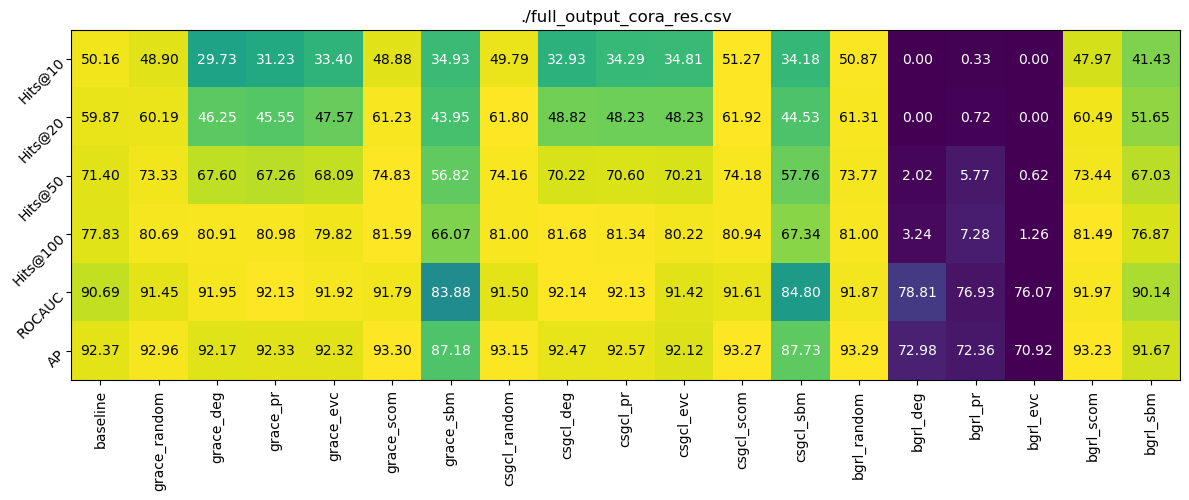

,baseline,grace_random,grace_deg,grace_pr,grace_evc,grace_scom,grace_sbm,csgcl_random,csgcl_deg,csgcl_pr,csgcl_evc,csgcl_scom,csgcl_sbm,bgrl_random,bgrl_deg,bgrl_pr,bgrl_evc,bgrl_scom,bgrl_sbm
metrics,,,,,,,,,,,,,,,,,,,
Hits@10,50.16$\pm$4.8,48.9$\pm$4.88,29.73$\pm$6.42,31.23$\pm$7.11,33.4$\pm$5.46,48.88$\pm$6.25,34.93$\pm$4.84,49.79$\pm$5.65,32.93$\pm$5.69,34.29$\pm$7.8,34.81$\pm$5.86,51.27$\pm$4.74,34.18$\pm$4.06,50.87$\pm$8.4,0.0$\pm$0.0,0.33$\pm$1.0,0.0$\pm$0.0,47.97$\pm$9.93,41.43$\pm$9.67
Hits@20,59.87$\pm$2.78,60.19$\pm$2.76,46.25$\pm$6.56,45.55$\pm$7.04,47.57$\pm$6.06,61.23$\pm$4.28,43.95$\pm$3.63,61.8$\pm$3.21,48.82$\pm$5.59,48.23$\pm$6.12,48.23$\pm$6.6,61.92$\pm$2.28,44.53$\pm$4.94,61.31$\pm$7.1,0.0$\pm$0.0,0.72$\pm$2.16,0.0$\pm$0.0,60.49$\pm$8.72,51.65$\pm$8.21
Hits@50,71.4$\pm$1.62,73.33$\pm$1.73,67.6$\pm$2.94,67.26$\pm$5.77,68.09$\pm$3.75,74.83$\pm$1.53,56.82$\pm$2.11,74.16$\pm$1.37,70.22$\pm$3.9,70.6$\pm$3.75,70.21$\pm$3.58,74.18$\pm$1.78,57.76$\pm$2.0,73.77$\pm$3.23,2.02$\pm$6.06,5.77$\pm$13.32,0.62$\pm$1.85,73.44$\pm$2.55,67.03$\pm$7.43
Hits@100,77.83$\pm$2.01,80.69$\pm$1.6,80.91$\pm$1.33,80.98$\pm$3.51,79.82$\pm$3.37,81.59$\pm$1.4,66.07$\pm$2.04,81.0$\pm$1.57,81.68$\pm$2.01,81.34$\pm$1.0,80.22$\pm$2.28,80.94$\pm$0.86,67.34$\pm$1.44,81.0$\pm$1.32,3.24$\pm$9.73,7.28$\pm$16.34,1.26$\pm$3.78,81.49$\pm$1.35,76.87$\pm$4.31
ROCAUC,90.69$\pm$0.88,91.45$\pm$0.81,91.95$\pm$0.58,92.13$\pm$1.14,91.92$\pm$0.68,91.79$\pm$0.71,83.88$\pm$1.02,91.5$\pm$1.04,92.14$\pm$0.79,92.13$\pm$0.55,91.42$\pm$0.97,91.61$\pm$0.55,84.8$\pm$1.02,91.87$\pm$0.71,78.81$\pm$4.54,76.93$\pm$7.69,76.07$\pm$8.37,91.97$\pm$1.01,90.14$\pm$1.26
AP,92.37$\pm$0.67,92.96$\pm$0.6,92.17$\pm$0.69,92.33$\pm$1.19,92.32$\pm$0.81,93.3$\pm$0.44,87.18$\pm$0.72,93.15$\pm$0.63,92.47$\pm$0.65,92.57$\pm$0.49,92.12$\pm$0.88,93.27$\pm$0.38,87.73$\pm$0.78,93.29$\pm$0.71,72.98$\pm$4.74,72.36$\pm$6.79,70.92$\pm$7.4,93.23$\pm$0.53,91.67$\pm$1.51
pretrain_time,nan$\pm$nan,19.04$\pm$0.13,19.19$\pm$0.08,19.15$\pm$0.02,19.15$\pm$0.04,20.27$\pm$0.09,866.8$\pm$23.27,20.67$\pm$0.09,20.74$\pm$0.13,20.7$\pm$0.09,20.67$\pm$0.04,22.3$\pm$0.17,895.48$\pm$32.54,19.01$\pm$0.1,19.45$\pm$0.09,18.95$\pm$0.52,18.1$\pm$0.11,19.36$\pm$0.06,846.79$\pm$30.39


In [8]:
name = './full_output_cora_res.csv'
data = res_load(name)

print(name)
print(data.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
heatmap(data, name)
display(data.T)

## SBM sur synthetic et cora

### SBM or SBM2

./sbm_full_synthetic_1_res.csv


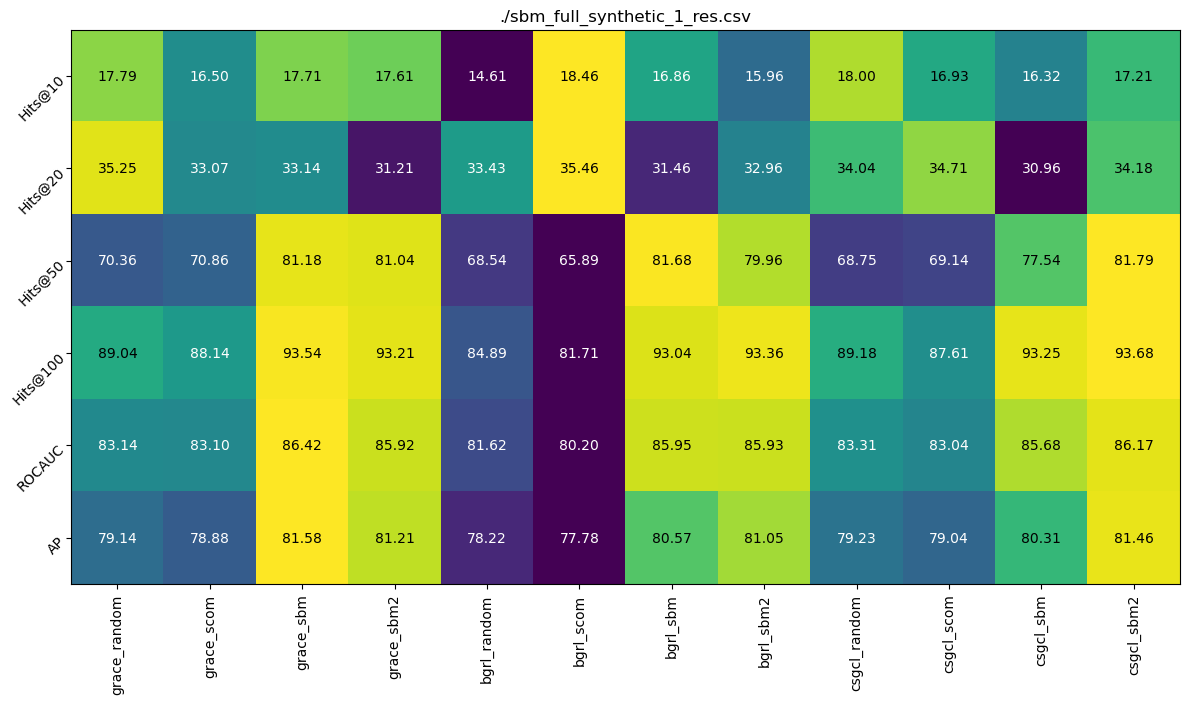

,grace_random,grace_scom,grace_sbm,grace_sbm2,bgrl_random,bgrl_scom,bgrl_sbm,bgrl_sbm2,csgcl_random,csgcl_scom,csgcl_sbm,csgcl_sbm2
metrics,,,,,,,,,,,,
Hits@10,17.79$\pm$7.26,16.5$\pm$6.84,17.71$\pm$5.37,17.61$\pm$5.64,14.61$\pm$5.13,18.46$\pm$5.39,16.86$\pm$6.29,15.96$\pm$6.4,18.0$\pm$7.55,16.93$\pm$5.01,16.32$\pm$3.46,17.21$\pm$4.68
Hits@20,35.25$\pm$9.67,33.07$\pm$7.54,33.14$\pm$8.16,31.21$\pm$5.66,33.43$\pm$4.9,35.46$\pm$7.6,31.46$\pm$7.55,32.96$\pm$7.97,34.04$\pm$7.78,34.71$\pm$10.31,30.96$\pm$8.71,34.18$\pm$6.47
Hits@50,70.36$\pm$4.24,70.86$\pm$5.75,81.18$\pm$10.02,81.04$\pm$11.84,68.54$\pm$4.18,65.89$\pm$5.62,81.68$\pm$8.13,79.96$\pm$10.64,68.75$\pm$4.41,69.14$\pm$4.3,77.54$\pm$9.67,81.79$\pm$9.16
Hits@100,89.04$\pm$0.6,88.14$\pm$2.23,93.54$\pm$1.12,93.21$\pm$1.01,84.89$\pm$2.36,81.71$\pm$3.6,93.04$\pm$0.7,93.36$\pm$0.89,89.18$\pm$1.86,87.61$\pm$1.81,93.25$\pm$1.4,93.68$\pm$0.78
ROCAUC,83.14$\pm$1.49,83.1$\pm$1.4,86.42$\pm$1.6,85.92$\pm$1.75,81.62$\pm$1.29,80.2$\pm$2.44,85.95$\pm$1.6,85.93$\pm$1.9,83.31$\pm$1.48,83.04$\pm$1.59,85.68$\pm$1.71,86.17$\pm$1.64
AP,79.14$\pm$2.4,78.88$\pm$2.35,81.58$\pm$2.58,81.21$\pm$2.81,78.22$\pm$2.21,77.78$\pm$2.43,80.57$\pm$2.55,81.05$\pm$2.6,79.23$\pm$2.53,79.04$\pm$2.52,80.31$\pm$2.55,81.46$\pm$2.34
pretrain_time,4.08$\pm$0.1,4.68$\pm$0.01,33.48$\pm$0.23,62.35$\pm$0.15,5.24$\pm$0.03,5.73$\pm$0.03,31.53$\pm$0.18,59.21$\pm$0.19,4.23$\pm$0.04,4.78$\pm$0.05,31.36$\pm$0.43,59.37$\pm$0.29


In [13]:
name = './sbm_full_synthetic_1_res.csv'
data_1 = res_load(name)

print(name)
# print(data_1.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data_1, name)
display(data_1.T)

./sbm_full_synthetic_2_res.csv


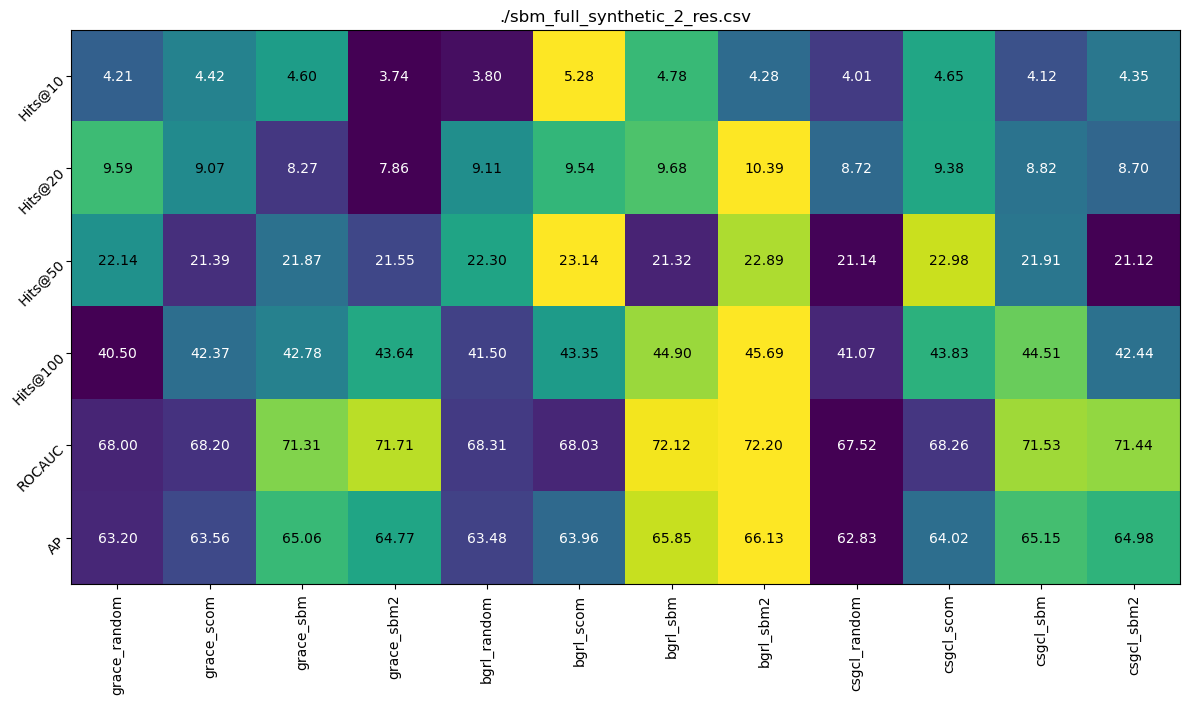

,grace_random,grace_scom,grace_sbm,grace_sbm2,bgrl_random,bgrl_scom,bgrl_sbm,bgrl_sbm2,csgcl_random,csgcl_scom,csgcl_sbm,csgcl_sbm2
metrics,,,,,,,,,,,,
Hits@10,4.21$\pm$1.93,4.42$\pm$0.92,4.6$\pm$1.26,3.74$\pm$1.5,3.8$\pm$1.7,5.28$\pm$1.57,4.78$\pm$1.69,4.28$\pm$1.75,4.01$\pm$1.44,4.65$\pm$1.22,4.12$\pm$1.62,4.35$\pm$2.53
Hits@20,9.59$\pm$2.41,9.07$\pm$2.06,8.27$\pm$1.92,7.86$\pm$2.03,9.11$\pm$2.59,9.54$\pm$1.77,9.68$\pm$2.45,10.39$\pm$2.07,8.72$\pm$2.03,9.38$\pm$2.08,8.82$\pm$2.3,8.7$\pm$3.22
Hits@50,22.14$\pm$4.09,21.39$\pm$4.06,21.87$\pm$2.69,21.55$\pm$2.52,22.3$\pm$2.7,23.14$\pm$5.6,21.32$\pm$3.88,22.89$\pm$2.82,21.14$\pm$2.58,22.98$\pm$4.05,21.91$\pm$2.88,21.12$\pm$3.54
Hits@100,40.5$\pm$5.55,42.37$\pm$4.4,42.78$\pm$3.2,43.64$\pm$3.57,41.5$\pm$2.49,43.35$\pm$5.29,44.9$\pm$5.4,45.69$\pm$5.24,41.07$\pm$3.66,43.83$\pm$4.44,44.51$\pm$3.94,42.44$\pm$3.27
ROCAUC,68.0$\pm$2.32,68.2$\pm$2.15,71.31$\pm$1.51,71.71$\pm$1.48,68.31$\pm$2.92,68.03$\pm$3.26,72.12$\pm$1.57,72.2$\pm$1.94,67.52$\pm$2.26,68.26$\pm$2.71,71.53$\pm$1.44,71.44$\pm$1.57
AP,63.2$\pm$2.67,63.56$\pm$2.21,65.06$\pm$1.51,64.77$\pm$1.77,63.48$\pm$2.62,63.96$\pm$3.21,65.85$\pm$2.32,66.13$\pm$2.27,62.83$\pm$2.43,64.02$\pm$2.56,65.15$\pm$1.91,64.98$\pm$1.81
pretrain_time,3.96$\pm$0.05,4.55$\pm$0.05,47.69$\pm$0.26,91.37$\pm$0.69,4.89$\pm$0.04,5.47$\pm$0.04,47.25$\pm$0.33,90.88$\pm$0.53,4.17$\pm$0.07,4.76$\pm$0.04,48.1$\pm$0.41,91.92$\pm$1.04


In [14]:
name = './sbm_full_synthetic_2_res.csv'
data_2 = res_load(name)

print(name)
# print(data_2.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data_2, name)
display(data_2.T)

./sbm_full_synthetic_3_res.csv


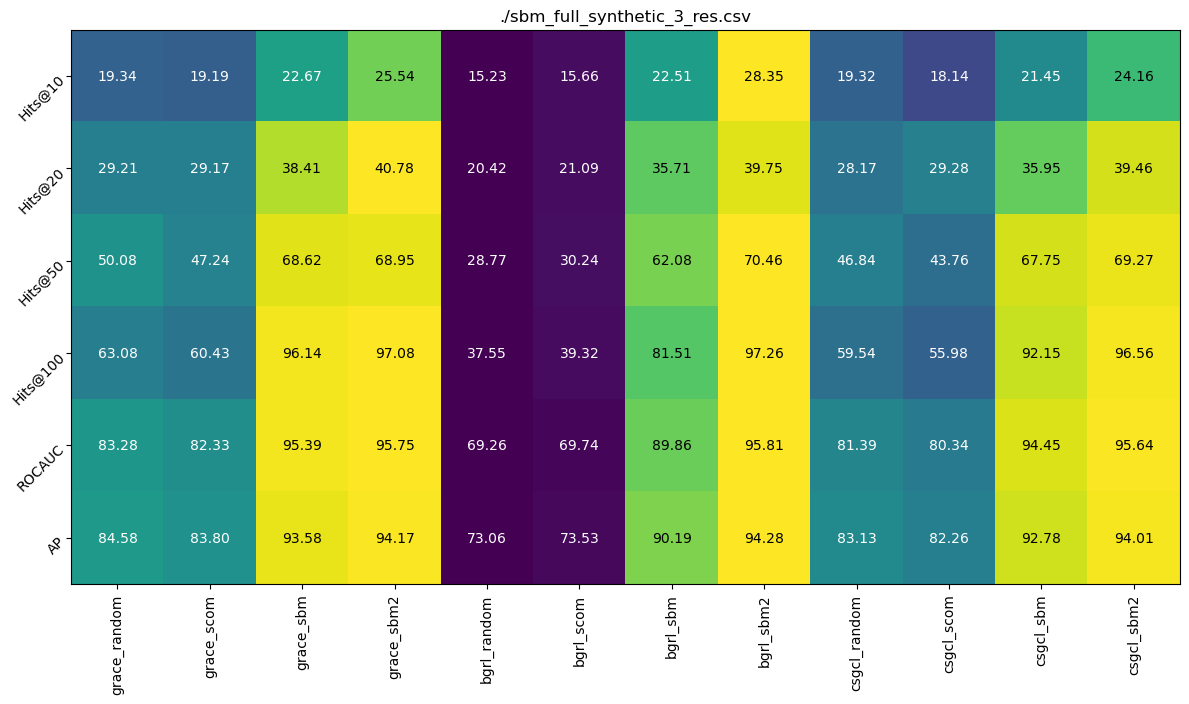

,grace_random,grace_scom,grace_sbm,grace_sbm2,bgrl_random,bgrl_scom,bgrl_sbm,bgrl_sbm2,csgcl_random,csgcl_scom,csgcl_sbm,csgcl_sbm2
metrics,,,,,,,,,,,,
Hits@10,19.34$\pm$4.15,19.19$\pm$2.74,22.67$\pm$6.13,25.54$\pm$5.67,15.23$\pm$2.37,15.66$\pm$3.57,22.51$\pm$5.06,28.35$\pm$6.23,19.32$\pm$4.25,18.14$\pm$2.39,21.45$\pm$5.94,24.16$\pm$6.63
Hits@20,29.21$\pm$4.44,29.17$\pm$4.24,38.41$\pm$9.15,40.78$\pm$7.11,20.42$\pm$2.42,21.09$\pm$2.47,35.71$\pm$6.88,39.75$\pm$6.29,28.17$\pm$3.91,29.28$\pm$3.54,35.95$\pm$8.11,39.46$\pm$6.89
Hits@50,50.08$\pm$3.33,47.24$\pm$3.29,68.62$\pm$6.61,68.95$\pm$8.8,28.77$\pm$1.88,30.24$\pm$1.61,62.08$\pm$5.08,70.46$\pm$8.64,46.84$\pm$3.1,43.76$\pm$2.63,67.75$\pm$7.61,69.27$\pm$8.01
Hits@100,63.08$\pm$1.66,60.43$\pm$2.02,96.14$\pm$1.98,97.08$\pm$2.71,37.55$\pm$2.57,39.32$\pm$1.69,81.51$\pm$7.9,97.26$\pm$2.35,59.54$\pm$2.13,55.98$\pm$2.03,92.15$\pm$2.47,96.56$\pm$2.03
ROCAUC,83.28$\pm$0.68,82.33$\pm$0.91,95.39$\pm$0.71,95.75$\pm$0.6,69.26$\pm$1.66,69.74$\pm$0.94,89.86$\pm$3.55,95.81$\pm$0.59,81.39$\pm$1.22,80.34$\pm$0.98,94.45$\pm$0.68,95.64$\pm$0.62
AP,84.58$\pm$0.6,83.8$\pm$0.97,93.58$\pm$1.19,94.17$\pm$0.94,73.06$\pm$1.57,73.53$\pm$0.81,90.19$\pm$2.24,94.28$\pm$0.84,83.13$\pm$1.14,82.26$\pm$0.9,92.78$\pm$1.1,94.01$\pm$0.92
pretrain_time,6.92$\pm$0.01,7.56$\pm$0.01,177.71$\pm$0.41,350.9$\pm$1.0,6.46$\pm$0.03,7.03$\pm$0.02,178.35$\pm$0.39,351.51$\pm$1.06,7.42$\pm$0.04,7.9$\pm$0.05,177.93$\pm$0.22,350.53$\pm$0.97


In [15]:
name = './sbm_full_synthetic_3_res.csv'
data_3 = res_load(name)

print(name)
# print(data_3.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data_3, name)
display(data_3.T)

In [ ]:
for data in [data_1, data_2, data_3]:
    for column in data.columns:
        data[column] = data[column].apply(extract_mean).apply(np.mean)
data = pd.concat((data_1, data_2, data_3), axis=1)
for column in data.columns.unique():
    data[column+'avg'] = data[column].mean(1)
data = data[data.columns.contains]

metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC,AP,pretrain_time,Hits@10,Hits@20,Hits@50,...,ROCAUC,AP,pretrain_time,Hits@10avg,Hits@20avg,Hits@50avg,Hits@100avg,ROCAUCavg,APavg,pretrain_timeavg
grace_random,17.79,35.25,70.36,89.04,83.14,79.14,4.08,4.21,9.59,22.14,...,83.28,84.58,6.92,13.780000,24.683333,47.526667,64.206667,78.140000,75.640000,4.986667
grace_scom,16.50,33.07,70.86,88.14,83.10,78.88,4.68,4.42,9.07,21.39,...,82.33,83.80,7.56,13.370000,23.770000,46.496667,63.646667,77.876667,75.413333,5.596667
grace_sbm,17.71,33.14,81.18,93.54,86.42,81.58,33.48,4.60,8.27,21.87,...,95.39,93.58,177.71,14.993333,26.606667,57.223333,77.486667,84.373333,80.073333,86.293333
grace_sbm2,17.61,31.21,81.04,93.21,85.92,81.21,62.35,3.74,7.86,21.55,...,95.75,94.17,350.90,15.630000,26.616667,57.180000,77.976667,84.460000,80.050000,168.206667
bgrl_random,14.61,33.43,68.54,84.89,81.62,78.22,5.24,3.80,9.11,22.30,...,69.26,73.06,6.46,11.213333,20.986667,39.870000,54.646667,73.063333,71.586667,5.530000
bgrl_scom,18.46,35.46,65.89,81.71,80.20,77.78,5.73,5.28,9.54,23.14,...,69.74,73.53,7.03,13.133333,22.030000,39.756667,54.793333,72.656667,71.756667,6.076667
bgrl_sbm,16.86,31.46,81.68,93.04,85.95,80.57,31.53,4.78,9.68,21.32,...,89.86,90.19,178.35,14.716667,25.616667,55.026667,73.150000,82.643333,78.870000,85.710000
bgrl_sbm2,15.96,32.96,79.96,93.36,85.93,81.05,59.21,4.28,10.39,22.89,...,95.81,94.28,351.51,16.196667,27.700000,57.770000,78.770000,84.646667,80.486667,167.200000
csgcl_random,18.00,34.04,68.75,89.18,83.31,79.23,4.23,4.01,8.72,21.14,...,81.39,83.13,7.42,13.776667,23.643333,45.576667,63.263333,77.406667,75.063333,5.273333
csgcl_scom,16.93,34.71,69.14,87.61,83.04,79.04,4.78,4.65,9.38,22.98,...,80.34,82.26,7.90,13.240000,24.456667,45.293333,62.473333,77.213333,75.106667,5.813333


### Resistance to variance

./SBM_var_synthetic_1_res.csv


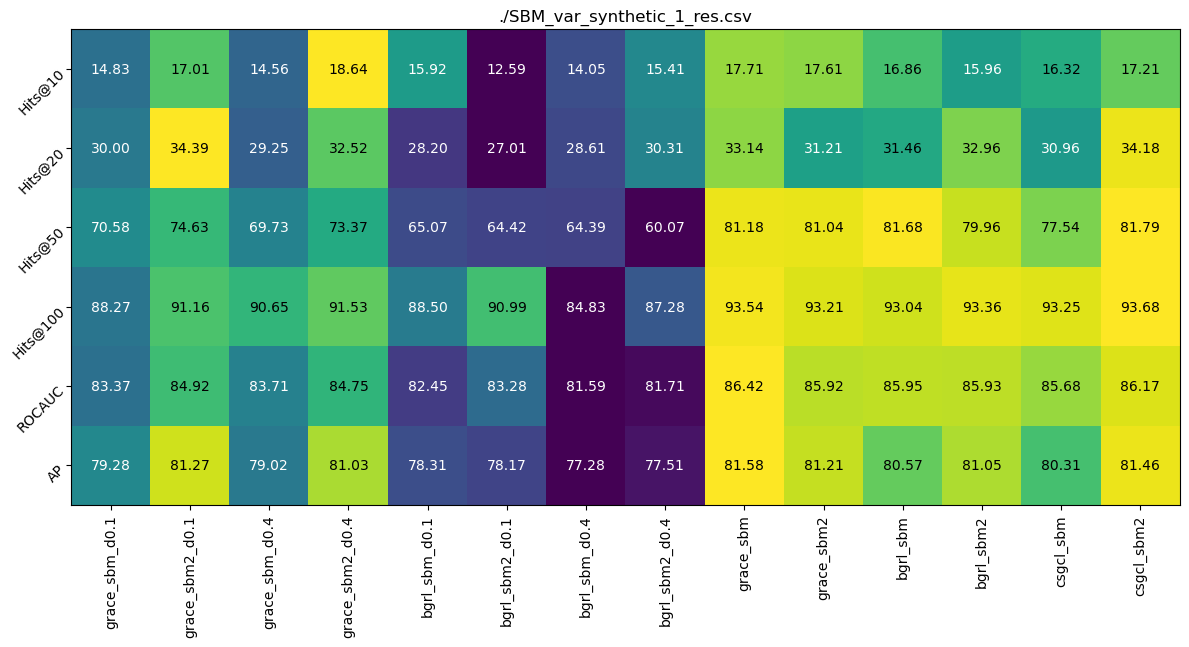

,grace_sbm_d0.1,grace_sbm2_d0.1,grace_sbm_d0.4,grace_sbm2_d0.4,bgrl_sbm_d0.1,bgrl_sbm2_d0.1,bgrl_sbm_d0.4,bgrl_sbm2_d0.4,grace_sbm,grace_sbm2,bgrl_sbm,bgrl_sbm2,csgcl_sbm,csgcl_sbm2
metrics,,,,,,,,,,,,,,
Hits@10,14.83$\pm$5.72,17.01$\pm$5.02,14.56$\pm$5.83,18.64$\pm$3.49,15.92$\pm$4.27,12.59$\pm$5.25,14.05$\pm$3.79,15.41$\pm$4.9,17.71$\pm$5.37,17.61$\pm$5.64,16.86$\pm$6.29,15.96$\pm$6.4,16.32$\pm$3.46,17.21$\pm$4.68
Hits@20,30.0$\pm$7.73,34.39$\pm$6.33,29.25$\pm$6.8,32.52$\pm$6.45,28.2$\pm$5.21,27.01$\pm$7.92,28.61$\pm$5.1,30.31$\pm$6.12,33.14$\pm$8.16,31.21$\pm$5.66,31.46$\pm$7.55,32.96$\pm$7.97,30.96$\pm$8.71,34.18$\pm$6.47
Hits@50,70.58$\pm$11.69,74.63$\pm$8.36,69.73$\pm$9.38,73.37$\pm$10.89,65.07$\pm$8.01,64.42$\pm$11.23,64.39$\pm$9.9,60.07$\pm$10.0,81.18$\pm$10.02,81.04$\pm$11.84,81.68$\pm$8.13,79.96$\pm$10.64,77.54$\pm$9.67,81.79$\pm$9.16
Hits@100,88.27$\pm$4.13,91.16$\pm$1.67,90.65$\pm$1.95,91.53$\pm$1.54,88.5$\pm$2.06,90.99$\pm$2.27,84.83$\pm$4.3,87.28$\pm$5.7,93.54$\pm$1.12,93.21$\pm$1.01,93.04$\pm$0.7,93.36$\pm$0.89,93.25$\pm$1.4,93.68$\pm$0.78
ROCAUC,83.37$\pm$2.99,84.92$\pm$1.81,83.71$\pm$2.1,84.75$\pm$1.41,82.45$\pm$1.57,83.28$\pm$1.81,81.59$\pm$2.29,81.71$\pm$3.06,86.42$\pm$1.6,85.92$\pm$1.75,85.95$\pm$1.6,85.93$\pm$1.9,85.68$\pm$1.71,86.17$\pm$1.64
AP,79.28$\pm$4.19,81.27$\pm$2.63,79.02$\pm$3.24,81.03$\pm$2.04,78.31$\pm$2.45,78.17$\pm$2.53,77.28$\pm$2.77,77.51$\pm$3.27,81.58$\pm$2.58,81.21$\pm$2.81,80.57$\pm$2.55,81.05$\pm$2.6,80.31$\pm$2.55,81.46$\pm$2.34
pretrain_time,50.37$\pm$8.91,125.0$\pm$46.66,79.41$\pm$16.14,210.32$\pm$65.48,134.08$\pm$33.92,248.46$\pm$66.17,141.26$\pm$40.1,328.41$\pm$107.95,33.48$\pm$0.23,62.35$\pm$0.15,31.53$\pm$0.18,59.21$\pm$0.19,31.36$\pm$0.43,59.37$\pm$0.29


In [5]:
name_1 = './SBM_var_synthetic_1_res.csv'
data_1 = res_load(name_1)

name_2 = './sbm_full_synthetic_1_res.csv'
data_2 = res_load(name_2)
data_2 = data_2[data_2.index.str.contains('sbm', case=False)]

data = pd.concat((data_1, data_2))



print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name_1": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name_1)
display(data.T)

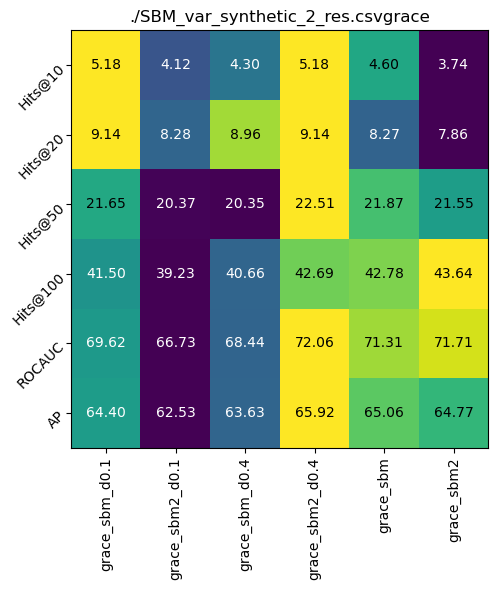

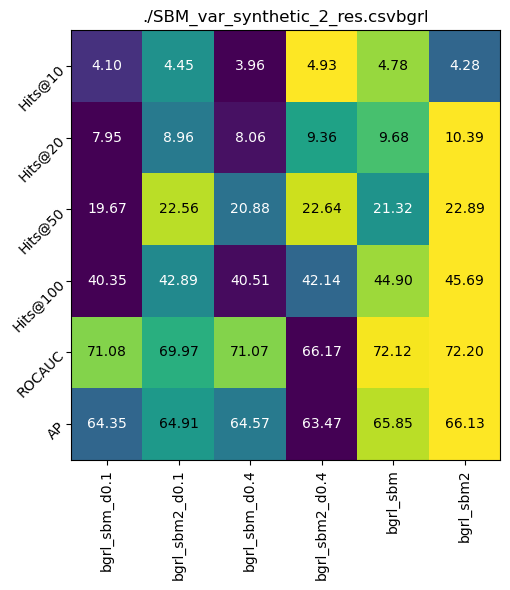

./SBM_var_synthetic_2_res.csv


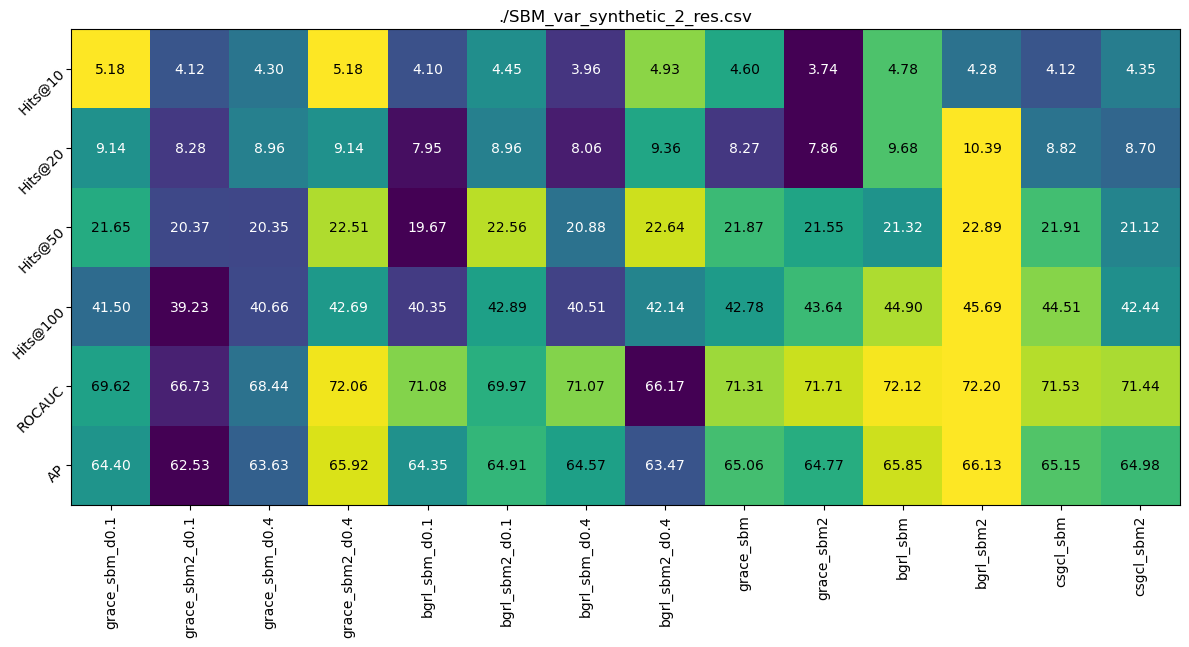

,grace_sbm_d0.1,grace_sbm2_d0.1,grace_sbm_d0.4,grace_sbm2_d0.4,bgrl_sbm_d0.1,bgrl_sbm2_d0.1,bgrl_sbm_d0.4,bgrl_sbm2_d0.4,grace_sbm,grace_sbm2,bgrl_sbm,bgrl_sbm2,csgcl_sbm,csgcl_sbm2
metrics,,,,,,,,,,,,,,
Hits@10,5.18$\pm$1.39,4.12$\pm$1.7,4.3$\pm$1.54,5.18$\pm$2.02,4.1$\pm$1.59,4.45$\pm$1.22,3.96$\pm$1.35,4.93$\pm$2.19,4.6$\pm$1.26,3.74$\pm$1.5,4.78$\pm$1.69,4.28$\pm$1.75,4.12$\pm$1.62,4.35$\pm$2.53
Hits@20,9.14$\pm$2.06,8.28$\pm$2.88,8.96$\pm$2.74,9.14$\pm$2.26,7.95$\pm$2.23,8.96$\pm$2.38,8.06$\pm$1.65,9.36$\pm$2.31,8.27$\pm$1.92,7.86$\pm$2.03,9.68$\pm$2.45,10.39$\pm$2.07,8.82$\pm$2.3,8.7$\pm$3.22
Hits@50,21.65$\pm$4.47,20.37$\pm$5.59,20.35$\pm$2.83,22.51$\pm$3.57,19.67$\pm$3.28,22.56$\pm$3.6,20.88$\pm$3.03,22.64$\pm$2.96,21.87$\pm$2.69,21.55$\pm$2.52,21.32$\pm$3.88,22.89$\pm$2.82,21.91$\pm$2.88,21.12$\pm$3.54
Hits@100,41.5$\pm$5.82,39.23$\pm$8.47,40.66$\pm$5.07,42.69$\pm$4.56,40.35$\pm$3.24,42.89$\pm$2.89,40.51$\pm$4.29,42.14$\pm$4.33,42.78$\pm$3.2,43.64$\pm$3.57,44.9$\pm$5.4,45.69$\pm$5.24,44.51$\pm$3.94,42.44$\pm$3.27
ROCAUC,69.62$\pm$4.32,66.73$\pm$8.77,68.44$\pm$5.89,72.06$\pm$1.48,71.08$\pm$0.88,69.97$\pm$5.97,71.07$\pm$1.46,66.17$\pm$8.33,71.31$\pm$1.51,71.71$\pm$1.48,72.12$\pm$1.57,72.2$\pm$1.94,71.53$\pm$1.44,71.44$\pm$1.57
AP,64.4$\pm$3.34,62.53$\pm$5.88,63.63$\pm$3.73,65.92$\pm$1.98,64.35$\pm$1.24,64.91$\pm$3.17,64.57$\pm$1.64,63.47$\pm$3.44,65.06$\pm$1.51,64.77$\pm$1.77,65.85$\pm$2.32,66.13$\pm$2.27,65.15$\pm$1.91,64.98$\pm$1.81
pretrain_time,66.62$\pm$29.24,292.5$\pm$157.79,223.42$\pm$117.4,538.72$\pm$384.47,315.0$\pm$205.53,650.13$\pm$475.79,449.71$\pm$259.72,992.57$\pm$646.82,47.69$\pm$0.26,91.37$\pm$0.69,47.25$\pm$0.33,90.88$\pm$0.53,48.1$\pm$0.41,91.92$\pm$1.04


In [12]:
name_1 = './SBM_var_synthetic_2_res.csv'
data_1 = res_load(name_1)

name_2 = './sbm_full_synthetic_2_res.csv'
data_2 = res_load(name_2)
data_2 = data_2[data_2.index.str.contains('sbm', case=False)]

data = pd.concat((data_1, data_2))
data_grace = data[data.index.str.contains('grace', case=False)]
heatmap(data_grace, name_1+'grace', (6,6))

data_bgrl = data[data.index.str.contains('bgrl', case=False)]
heatmap(data_bgrl, name_1+'bgrl', (6,6))

print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name_1": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name_1)
display(data.T)

./sbm_full_cora_res.csv


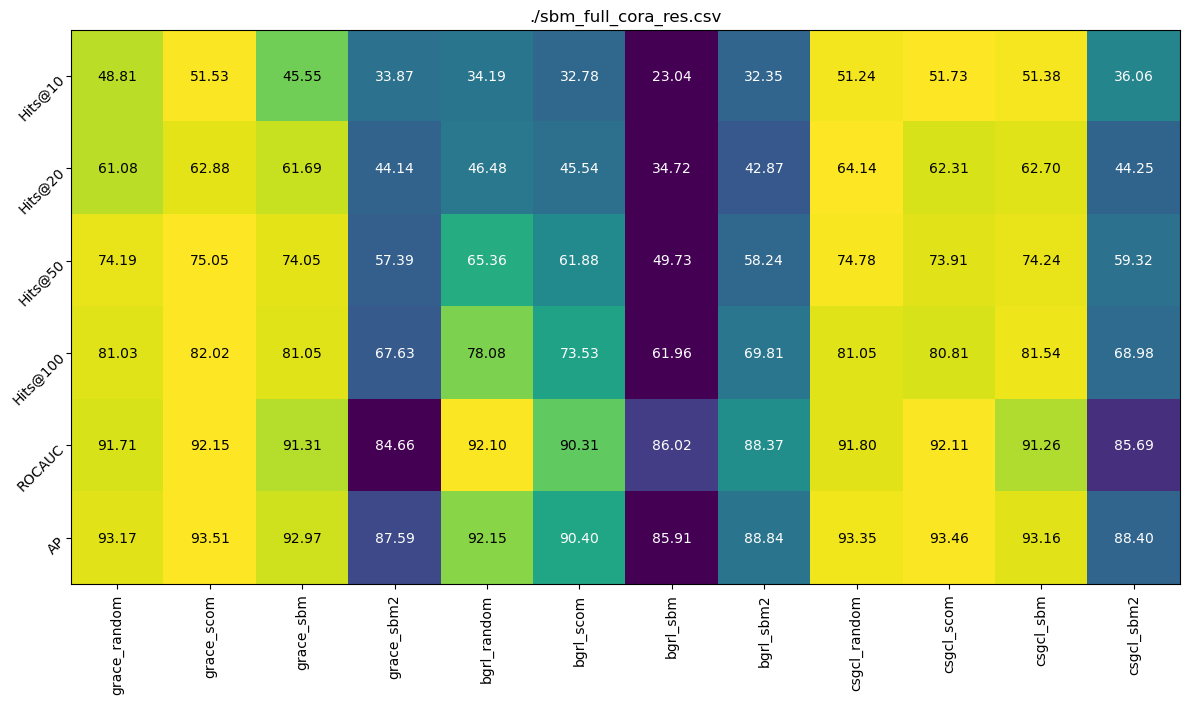

,grace_random,grace_scom,grace_sbm,grace_sbm2,bgrl_random,bgrl_scom,bgrl_sbm,bgrl_sbm2,csgcl_random,csgcl_scom,csgcl_sbm,csgcl_sbm2
metrics,,,,,,,,,,,,
Hits@10,48.81$\pm$4.21,51.53$\pm$4.99,45.55$\pm$6.71,33.87$\pm$3.08,34.19$\pm$6.69,32.78$\pm$13.51,23.04$\pm$11.89,32.35$\pm$13.55,51.24$\pm$4.54,51.73$\pm$3.4,51.38$\pm$4.99,36.06$\pm$3.66
Hits@20,61.08$\pm$3.09,62.88$\pm$2.16,61.69$\pm$4.64,44.14$\pm$2.48,46.48$\pm$6.42,45.54$\pm$14.39,34.72$\pm$15.35,42.87$\pm$15.22,64.14$\pm$2.19,62.31$\pm$3.06,62.7$\pm$4.11,44.25$\pm$2.66
Hits@50,74.19$\pm$1.7,75.05$\pm$0.82,74.05$\pm$1.86,57.39$\pm$2.7,65.36$\pm$5.51,61.88$\pm$16.1,49.73$\pm$17.42,58.24$\pm$16.63,74.78$\pm$1.8,73.91$\pm$1.35,74.24$\pm$1.91,59.32$\pm$1.9
Hits@100,81.03$\pm$1.68,82.02$\pm$0.83,81.05$\pm$1.57,67.63$\pm$2.3,78.08$\pm$4.21,73.53$\pm$15.19,61.96$\pm$17.22,69.81$\pm$16.48,81.05$\pm$0.97,80.81$\pm$1.46,81.54$\pm$1.58,68.98$\pm$1.74
ROCAUC,91.71$\pm$1.01,92.15$\pm$0.44,91.31$\pm$0.8,84.66$\pm$1.36,92.1$\pm$1.03,90.31$\pm$5.91,86.02$\pm$8.6,88.37$\pm$6.56,91.8$\pm$0.73,92.11$\pm$0.64,91.26$\pm$0.78,85.69$\pm$1.17
AP,93.17$\pm$0.7,93.51$\pm$0.2,92.97$\pm$0.58,87.59$\pm$0.97,92.15$\pm$1.19,90.4$\pm$6.21,85.91$\pm$8.51,88.84$\pm$6.64,93.35$\pm$0.4,93.46$\pm$0.38,93.16$\pm$0.5,88.4$\pm$0.82
pretrain_time,6.24$\pm$0.01,6.72$\pm$0.02,148.78$\pm$5.04,293.63$\pm$10.0,5.74$\pm$0.01,6.27$\pm$0.02,149.48$\pm$5.05,293.61$\pm$9.91,6.71$\pm$0.05,7.19$\pm$0.06,148.82$\pm$4.99,293.08$\pm$9.61


In [8]:
name = './sbm_full_cora_res.csv'
data = res_load(name)

print(name)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name)
display(data.T)

## SBM: Cora full vs CORA - test

SBM full vs -test cora
\begin{tabular}{lllllllll}
\toprule
 & metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & AP & pretrain_time \\
\midrule
\multirow[t]{4}{*}{full} & baseline & 46.82$\pm$0.0 & 55.26$\pm$0.0 & 68.25$\pm$0.0 & 77.16$\pm$0.0 & 90.45$\pm$0.0 & 91.84$\pm$0.0 & nan$\pm$nan \\
 & grace_sbm & 27.68$\pm$0.0 & 42.18$\pm$0.0 & 58.2$\pm$0.0 & 65.88$\pm$0.0 & 83.88$\pm$0.0 & 86.77$\pm$0.0 & 135.02$\pm$0.0 \\
 & csgcl_sbm & 36.02$\pm$0.0 & 48.82$\pm$0.0 & 58.86$\pm$0.0 & 68.44$\pm$0.0 & 85.37$\pm$0.0 & 88.41$\pm$0.0 & 135.5$\pm$0.0 \\
 & bgrl_sbm & 29.29$\pm$0.0 & 39.05$\pm$0.0 & 51.56$\pm$0.0 & 65.97$\pm$0.0 & 89.29$\pm$0.0 & 89.24$\pm$0.0 & 135.32$\pm$0.0 \\
\cline{1-9}
\multirow[t]{4}{*}{-test} & baseline & 46.82$\pm$0.0 & 55.26$\pm$0.0 & 68.25$\pm$0.0 & 77.16$\pm$0.0 & 90.45$\pm$0.0 & 91.84$\pm$0.0 & nan$\pm$nan \\
 & grace_sbm & 38.1$\pm$0.0 & 45.31$\pm$0.0 & 57.54$\pm$0.0 & 68.72$\pm$0.0 & 85.93$\pm$0.0 & 88.55$\pm$0.0 & 144.55$\pm$0.0 \\
 & csgcl_sbm & 33.18$\pm

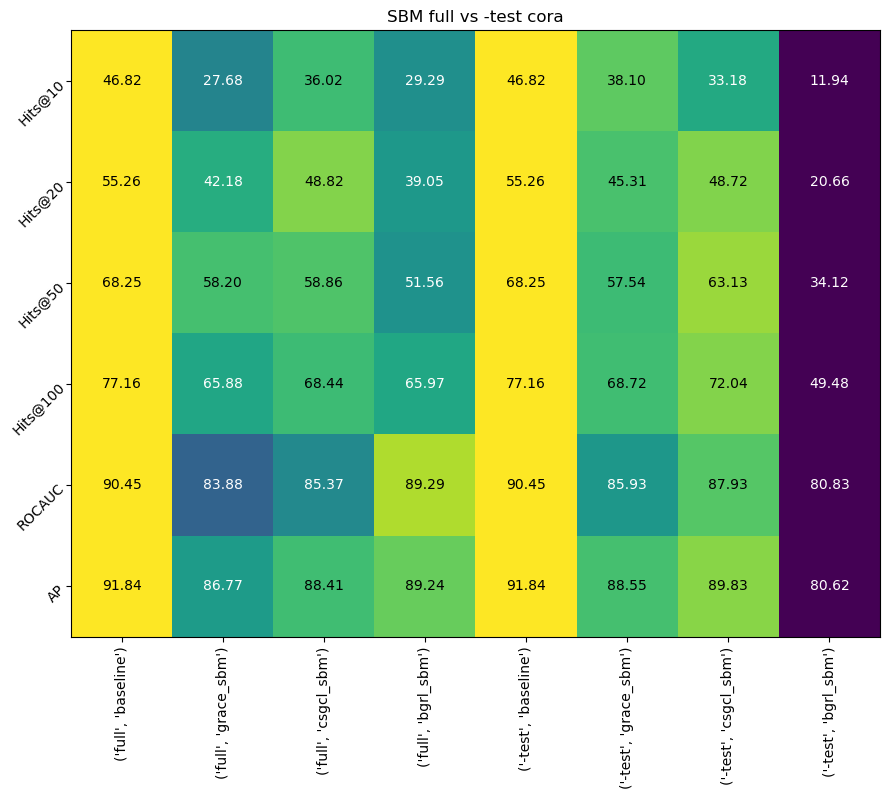

full                                                 \
                    baseline       grace_sbm      csgcl_sbm        bgrl_sbm   
metrics                                                                       
Hits@10        46.82$\pm$0.0   27.68$\pm$0.0  36.02$\pm$0.0   29.29$\pm$0.0   
Hits@20        55.26$\pm$0.0   42.18$\pm$0.0  48.82$\pm$0.0   39.05$\pm$0.0   
Hits@50        68.25$\pm$0.0    58.2$\pm$0.0  58.86$\pm$0.0   51.56$\pm$0.0   
Hits@100       77.16$\pm$0.0   65.88$\pm$0.0  68.44$\pm$0.0   65.97$\pm$0.0   
ROCAUC         90.45$\pm$0.0   83.88$\pm$0.0  85.37$\pm$0.0   89.29$\pm$0.0   
AP             91.84$\pm$0.0   86.77$\pm$0.0  88.41$\pm$0.0   89.24$\pm$0.0   
pretrain_time    nan$\pm$nan  135.02$\pm$0.0  135.5$\pm$0.0  135.32$\pm$0.0   

                       -test                                                  
                    baseline       grace_sbm       csgcl_sbm        bgrl_sbm  
metrics                                                                       
Hits@10        46.82$\pm$0.0    38.1$\pm$0.0   33.18$\pm$0.0   11.94$\pm$0.0  
Hits@20        55.26$\pm$0.0   45.31$\pm$0.0   48.72$\pm$0.0   20.66$\pm$0.0  
Hits@50        68.25$\pm$0.0   57.54$\pm$0.0   63.13$\pm$0.0   34.12$\pm$0.0  
Hits@100       77.16$\pm$0.0   68.72$\pm$0.0   72.04$\pm$0.0   49.48$\pm$0.0  
ROCAUC         90.45$\pm$0.0   85.93$\pm$0.0   87.93$\pm$0.0   80.83$\pm$0.0  
AP             91.84$\pm$0.0   88.55$\pm$0.0   89.83$\pm$0.0   80.62$\pm$0.0  
pretrain_time    nan$\pm$nan  144.55$\pm$0.0  144.32$\pm$0.0  144.34$\pm$0.0

In [11]:
name_1 = './cora_sbm_full_res.csv'
data_1 = res_load(name_1)

name_2 = './cora-test_sbm_res.csv'
data_2 = res_load(name_2)

data_sbm = pd.concat([data_1, data_2], keys=['full', '-test'])

print('SBM full vs -test cora')
print(data_sbm.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
heatmap(data_sbm, 'SBM full vs -test cora', (9,9))
display(data_sbm.T)

## loss tuning

### clustering based

./scgc_bgrl_cora_res.csv


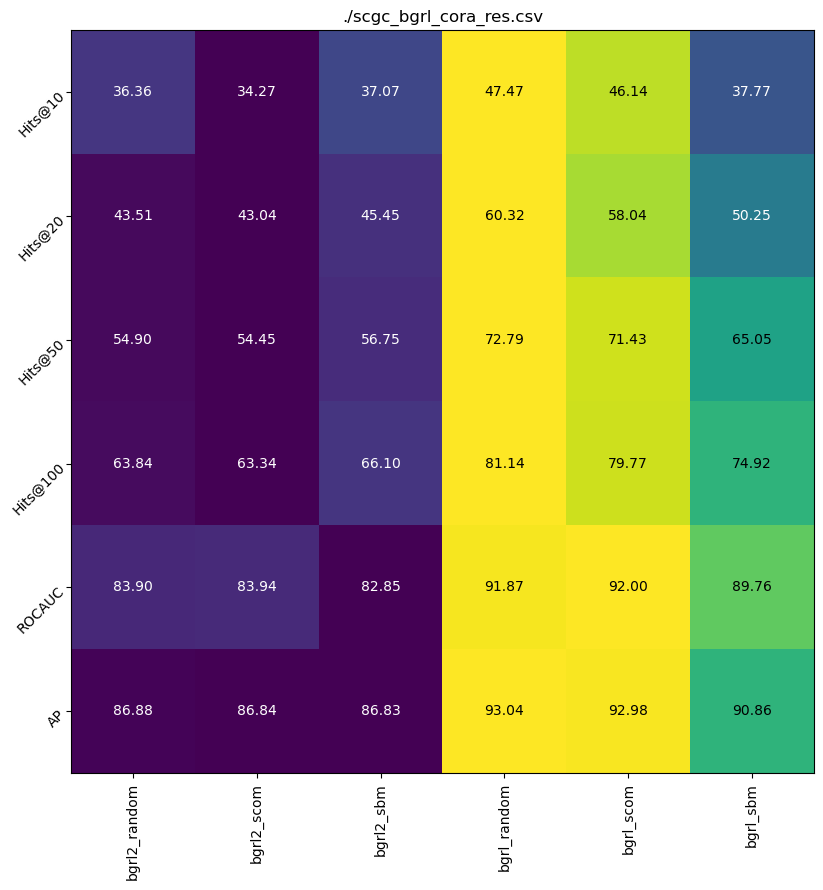

,bgrl2_random,bgrl2_scom,bgrl2_sbm,bgrl_random,bgrl_scom,bgrl_sbm
metrics,,,,,,
Hits@10,36.36$\pm$4.68,34.27$\pm$4.08,37.07$\pm$4.87,47.47$\pm$9.35,46.14$\pm$11.04,37.77$\pm$10.71
Hits@20,43.51$\pm$4.09,43.04$\pm$4.29,45.45$\pm$2.84,60.32$\pm$6.76,58.04$\pm$11.15,50.25$\pm$12.5
Hits@50,54.9$\pm$3.33,54.45$\pm$2.25,56.75$\pm$3.17,72.79$\pm$3.74,71.43$\pm$7.98,65.05$\pm$11.68
Hits@100,63.84$\pm$3.16,63.34$\pm$2.62,66.1$\pm$2.62,81.14$\pm$2.1,79.77$\pm$4.62,74.92$\pm$9.24
ROCAUC,83.9$\pm$1.52,83.94$\pm$1.59,82.85$\pm$1.43,91.87$\pm$1.08,92.0$\pm$0.91,89.76$\pm$2.91
AP,86.88$\pm$1.26,86.84$\pm$1.31,86.83$\pm$1.16,93.04$\pm$0.74,92.98$\pm$1.36,90.86$\pm$3.3
pretrain_time,17.21$\pm$5.5,25.22$\pm$7.97,1117.55$\pm$39.84,20.9$\pm$0.25,23.37$\pm$0.68,981.47$\pm$39.56


In [3]:
name = './scgc_bgrl_cora_res.csv'
data = res_load(name)

print(name)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name, (9,9))
display(data.T)

./cgrace_cora_res.csv


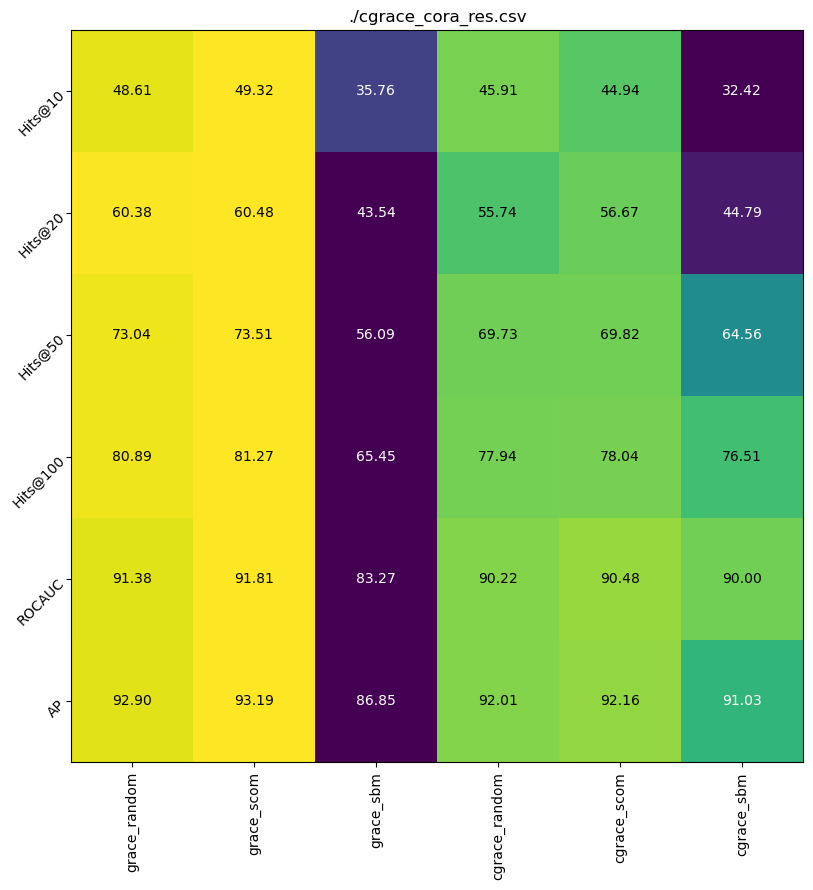

,grace_random,grace_scom,grace_sbm,cgrace_random,cgrace_scom,cgrace_sbm
metrics,,,,,,
Hits@10,48.61$\pm$3.7,49.32$\pm$6.01,35.76$\pm$3.88,45.91$\pm$4.71,44.94$\pm$5.28,32.42$\pm$5.29
Hits@20,60.38$\pm$2.55,60.48$\pm$4.56,43.54$\pm$3.48,55.74$\pm$3.58,56.67$\pm$2.86,44.79$\pm$5.69
Hits@50,73.04$\pm$2.12,73.51$\pm$2.4,56.09$\pm$1.49,69.73$\pm$1.75,69.82$\pm$1.42,64.56$\pm$3.78
Hits@100,80.89$\pm$1.4,81.27$\pm$1.58,65.45$\pm$1.7,77.94$\pm$1.35,78.04$\pm$0.98,76.51$\pm$1.68
ROCAUC,91.38$\pm$0.95,91.81$\pm$0.84,83.27$\pm$1.13,90.22$\pm$0.75,90.48$\pm$0.52,90.0$\pm$0.78
AP,92.9$\pm$0.58,93.19$\pm$0.51,86.85$\pm$0.79,92.01$\pm$0.5,92.16$\pm$0.42,91.03$\pm$0.74
pretrain_time,26.45$\pm$0.83,28.58$\pm$0.81,992.57$\pm$35.29,90.0$\pm$8.23,92.72$\pm$10.07,1006.58$\pm$44.02


In [4]:
name = './cgrace_cora_res.csv'
data = res_load(name)

print(name)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name, (9,9))
display(data.T)

## link loss

## Â

### Old test

./test_Agrace_mean_cora_res.csv


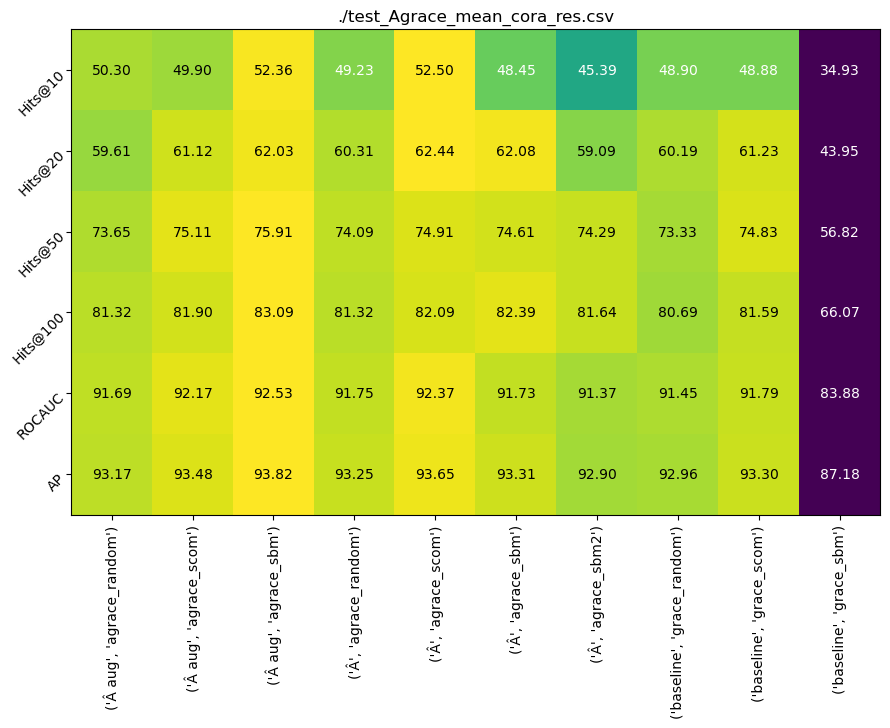

Â aug                                               Â  \
                agrace_random     agrace_scom      agrace_sbm   agrace_random   
metrics                                                                         
Hits@10         50.3$\pm$6.37   49.9$\pm$6.22  52.36$\pm$5.92  49.23$\pm$7.67   
Hits@20        59.61$\pm$5.93  61.12$\pm$3.73   62.03$\pm$4.4  60.31$\pm$4.82   
Hits@50        73.65$\pm$1.39  75.11$\pm$1.24  75.91$\pm$1.86  74.09$\pm$1.77   
Hits@100       81.32$\pm$1.05   81.9$\pm$1.04  83.09$\pm$1.27  81.32$\pm$1.35   
ROCAUC         91.69$\pm$0.69  92.17$\pm$0.57  92.53$\pm$0.51  91.75$\pm$0.75   
AP             93.17$\pm$0.57  93.48$\pm$0.38  93.82$\pm$0.41   93.25$\pm$0.6   
pretrain_time   5.91$\pm$0.95    5.17$\pm$0.1  88.78$\pm$2.62   3.11$\pm$0.07   

                                                                \
                  agrace_scom      agrace_sbm      agrace_sbm2   
metrics                                                          
Hits@10          52.5$\pm$4.6  48.45$\pm$6.75   45.39$\pm$4.61   
Hits@20        62.44$\pm$3.59  62.08$\pm$4.05   59.09$\pm$3.71   
Hits@50        74.91$\pm$1.52  74.61$\pm$2.46   74.29$\pm$1.21   
Hits@100       82.09$\pm$0.91  82.39$\pm$1.88   81.64$\pm$1.24   
ROCAUC          92.37$\pm$0.6  91.73$\pm$0.94   91.37$\pm$0.46   
AP             93.65$\pm$0.46  93.31$\pm$0.75    92.9$\pm$0.22   
pretrain_time    3.34$\pm$0.0   87.7$\pm$3.07  169.17$\pm$5.72   

                     baseline                                   
                 grace_random      grace_scom        grace_sbm  
metrics                                                         
Hits@10         48.9$\pm$4.88  48.88$\pm$6.25   34.93$\pm$4.84  
Hits@20        60.19$\pm$2.76  61.23$\pm$4.28   43.95$\pm$3.63  
Hits@50        73.33$\pm$1.73  74.83$\pm$1.53   56.82$\pm$2.11  
Hits@100        80.69$\pm$1.6   81.59$\pm$1.4   66.07$\pm$2.04  
ROCAUC         91.45$\pm$0.81  91.79$\pm$0.71   83.88$\pm$1.02  
AP              92.96$\pm$0.6   93.3$\pm$0.44   87.18$\pm$0.72  
pretrain_time  19.04$\pm$0.13  20.27$\pm$0.09  866.8$\pm$23.27

In [12]:
name_1 = './test_Agrace_mean_cora_res.csv'
data_1 = res_load(name_1)

name_2 = './full_output_cora_res.csv'
data_2 = res_load(name_2)
data_2 = data_2.T[['grace_random', 'grace_scom', 'grace_sbm']].T

name_3 = './test_augmented_Agrace_mean_cora_res.csv'
data_3 = res_load(name_3)
data = pd.concat([data_3, data_1, data_2], keys=['Â aug','Â', 'baseline'])


print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name_1, (9,9))
display(data.T)

./test_augmented_Abgrl_mean_synthetic_1_res.csv


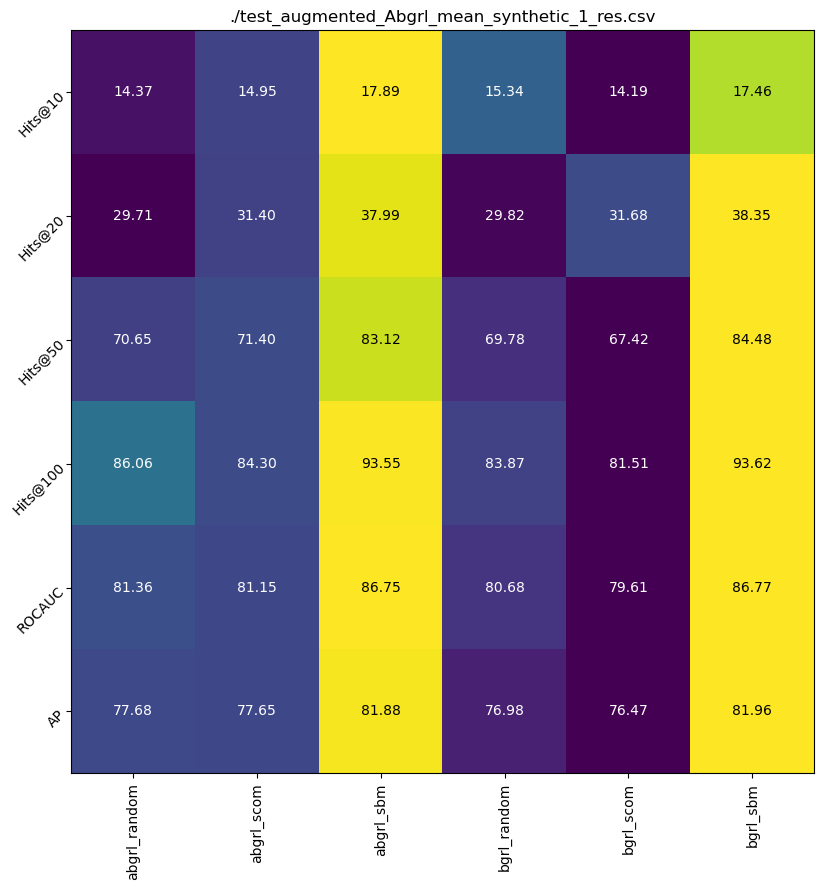

Â aug                                               Â  \
                agrace_random     agrace_scom      agrace_sbm   agrace_random   
metrics                                                                         
Hits@10         50.3$\pm$6.37   49.9$\pm$6.22  52.36$\pm$5.92  49.23$\pm$7.67   
Hits@20        59.61$\pm$5.93  61.12$\pm$3.73   62.03$\pm$4.4  60.31$\pm$4.82   
Hits@50        73.65$\pm$1.39  75.11$\pm$1.24  75.91$\pm$1.86  74.09$\pm$1.77   
Hits@100       81.32$\pm$1.05   81.9$\pm$1.04  83.09$\pm$1.27  81.32$\pm$1.35   
ROCAUC         91.69$\pm$0.69  92.17$\pm$0.57  92.53$\pm$0.51  91.75$\pm$0.75   
AP             93.17$\pm$0.57  93.48$\pm$0.38  93.82$\pm$0.41   93.25$\pm$0.6   
pretrain_time   5.91$\pm$0.95    5.17$\pm$0.1  88.78$\pm$2.62   3.11$\pm$0.07   

                                                                \
                  agrace_scom      agrace_sbm      agrace_sbm2   
metrics                                                          
Hits@10          52.5$\pm$4.6  48.45$\pm$6.75   45.39$\pm$4.61   
Hits@20        62.44$\pm$3.59  62.08$\pm$4.05   59.09$\pm$3.71   
Hits@50        74.91$\pm$1.52  74.61$\pm$2.46   74.29$\pm$1.21   
Hits@100       82.09$\pm$0.91  82.39$\pm$1.88   81.64$\pm$1.24   
ROCAUC          92.37$\pm$0.6  91.73$\pm$0.94   91.37$\pm$0.46   
AP             93.65$\pm$0.46  93.31$\pm$0.75    92.9$\pm$0.22   
pretrain_time    3.34$\pm$0.0   87.7$\pm$3.07  169.17$\pm$5.72   

                     baseline                                   
                 grace_random      grace_scom        grace_sbm  
metrics                                                         
Hits@10         48.9$\pm$4.88  48.88$\pm$6.25   34.93$\pm$4.84  
Hits@20        60.19$\pm$2.76  61.23$\pm$4.28   43.95$\pm$3.63  
Hits@50        73.33$\pm$1.73  74.83$\pm$1.53   56.82$\pm$2.11  
Hits@100        80.69$\pm$1.6   81.59$\pm$1.4   66.07$\pm$2.04  
ROCAUC         91.45$\pm$0.81  91.79$\pm$0.71   83.88$\pm$1.02  
AP              92.96$\pm$0.6   93.3$\pm$0.44   87.18$\pm$0.72  
pretrain_time  19.04$\pm$0.13  20.27$\pm$0.09  866.8$\pm$23.27

In [13]:
name_1 = './test_augmented_Abgrl_mean_synthetic_1_res.csv'
data_1 = res_load(name_1)

print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data_1, name_1, (9,9))
display(data.T)

### New test

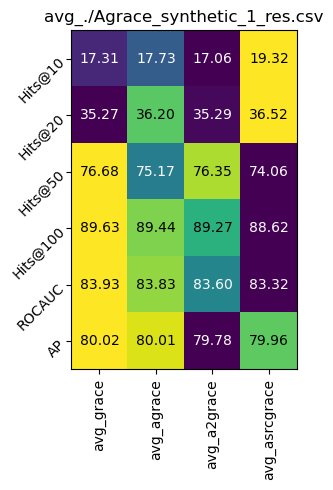

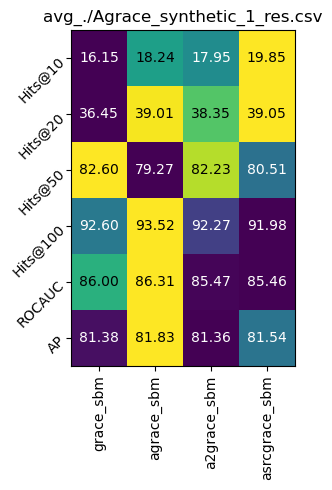

./Agrace_synthetic_1_res.csv


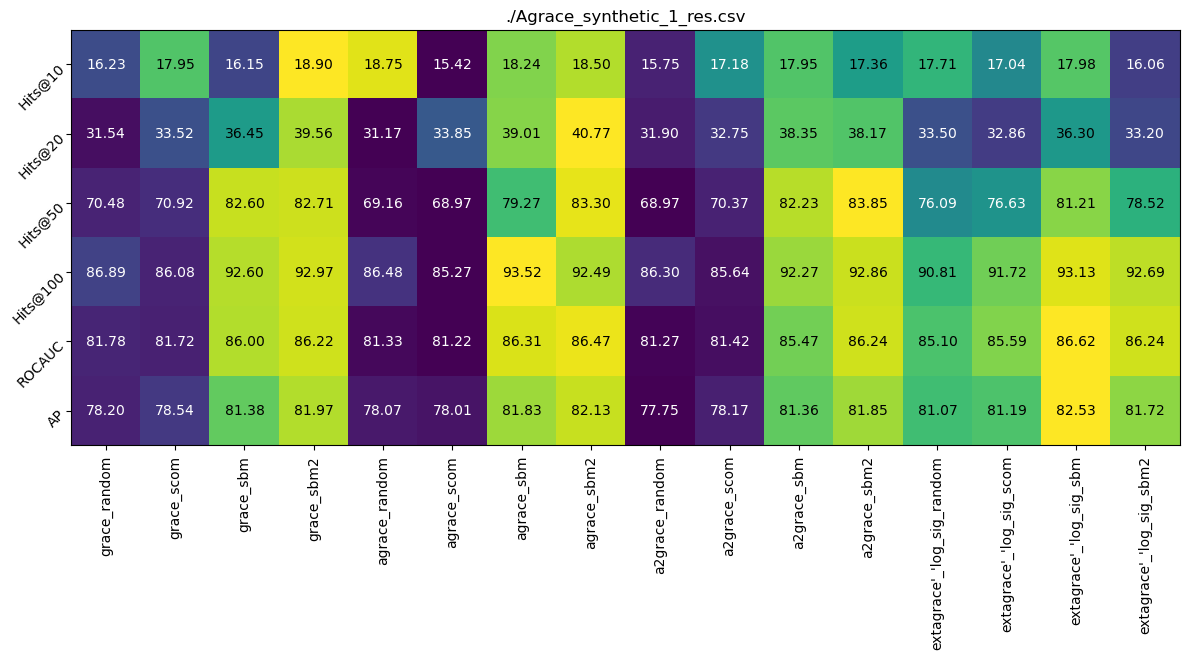

In [42]:
name_1 = './Agrace_synthetic_1_res.csv'
data_1 = res_load(name_1)

name_2 = './extended_synthetic_1_res.csv'
data_2 = res_load(name_2)
data_2 = data_2[~data_2.index.str.contains('bgrl', case=False)]

data = pd.concat((data_1, data_2))
data=data[~data.index.str.contains('src', case=False)]
data_1.loc['avg_grace'] = average_methods(data_1.loc[['grace_random', 'grace_scom', 'grace_sbm', 'grace_sbm2']])
data_1.loc['avg_agrace'] = average_methods(data_1.loc[['agrace_random', 'agrace_scom', 'agrace_sbm', 'agrace_sbm2']])
data_1.loc['avg_a2grace'] = average_methods(data_1.loc[['a2grace_random', 'a2grace_scom', 'a2grace_sbm', 'a2grace_sbm2']])
data_1.loc['avg_asrcgrace'] = average_methods(data_1.loc[['asrcgrace_random', 'asrcgrace_scom', 'asrcgrace_sbm', 'asrcgrace_sbm2']])
heatmap(data_1.loc[['avg_grace', 'avg_agrace', 'avg_a2grace', 'avg_asrcgrace']], 'avg_'+name_1, (5,5))
heatmap(data_1.loc[['grace_sbm', 'agrace_sbm', 'a2grace_sbm', 'asrcgrace_sbm']], 'avg_'+name_1, (5,5))
print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name_1, (12,12))

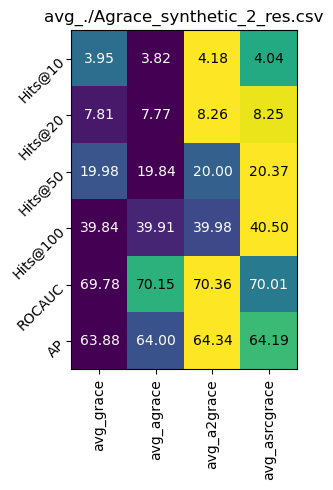

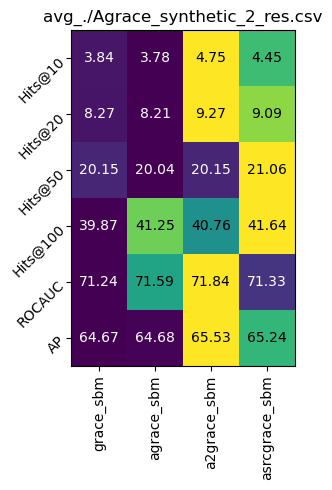

./Agrace_synthetic_2_res.csv


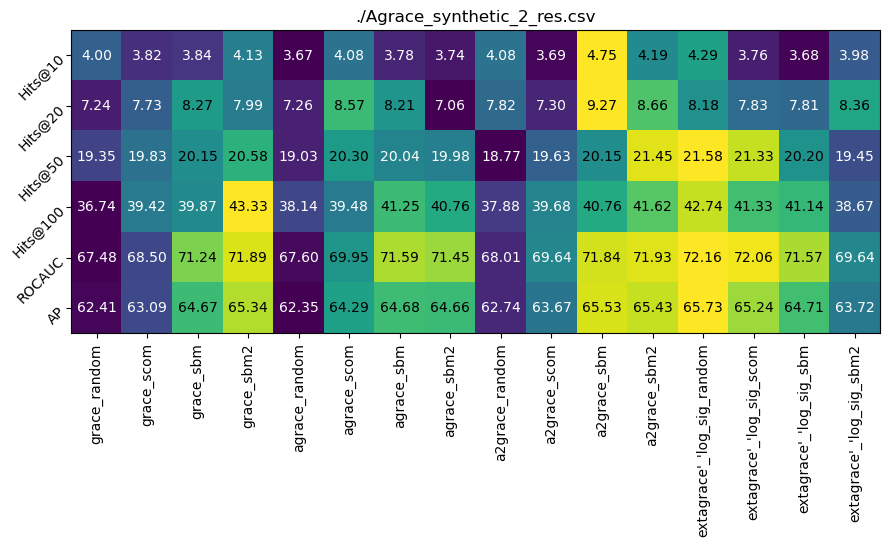

In [43]:
name_1 = './Agrace_synthetic_2_res.csv'
data_1 = res_load(name_1)

name_2 = './extended_synthetic_2_res.csv'
data_2 = res_load(name_2)
data_2 = data_2[~data_2.index.str.contains('bgrl', case=False)]

data = pd.concat((data_1, data_2))
data=data[~data.index.str.contains('src', case=False)]

data_1.loc['avg_grace'] = average_methods(data_1.loc[['grace_random', 'grace_scom', 'grace_sbm', 'grace_sbm2']])
data_1.loc['avg_agrace'] = average_methods(data_1.loc[['agrace_random', 'agrace_scom', 'agrace_sbm', 'agrace_sbm2']])
data_1.loc['avg_a2grace'] = average_methods(data_1.loc[['a2grace_random', 'a2grace_scom', 'a2grace_sbm', 'a2grace_sbm2']])
data_1.loc['avg_asrcgrace'] = average_methods(data_1.loc[['asrcgrace_random', 'asrcgrace_scom', 'asrcgrace_sbm', 'asrcgrace_sbm2']])
heatmap(data_1.loc[['avg_grace', 'avg_agrace', 'avg_a2grace', 'avg_asrcgrace']], 'avg_'+name_1, (5,5))
heatmap(data_1.loc[['grace_sbm', 'agrace_sbm', 'a2grace_sbm', 'asrcgrace_sbm']], 'avg_'+name_1, (5,5))

print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name_1, (9,9))

./Agrace_synthetic_3_res.csv


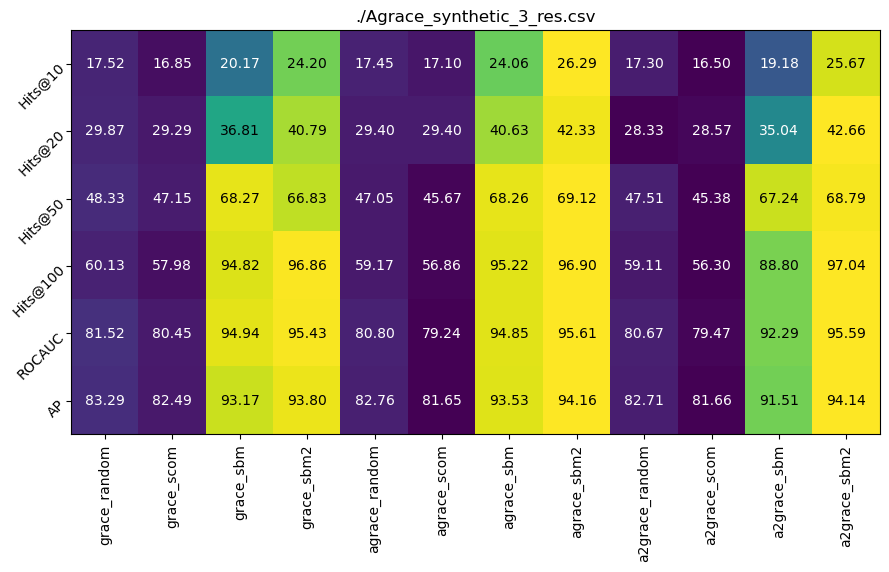

In [59]:
name_1 = './Agrace_synthetic_3_res.csv'
data = res_load(name_1)

print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
data=data[~data.index.str.contains('src', case=False)]

heatmap(data, name_1, (9,9))

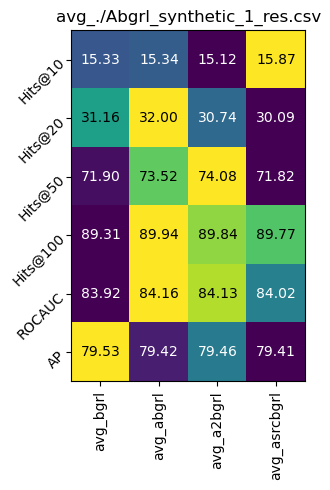

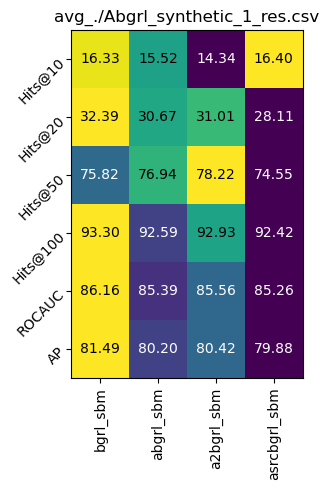

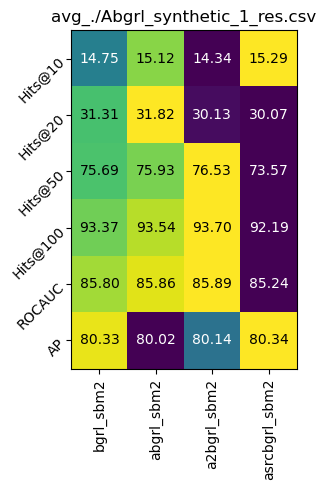

./Abgrl_synthetic_1_res.csv


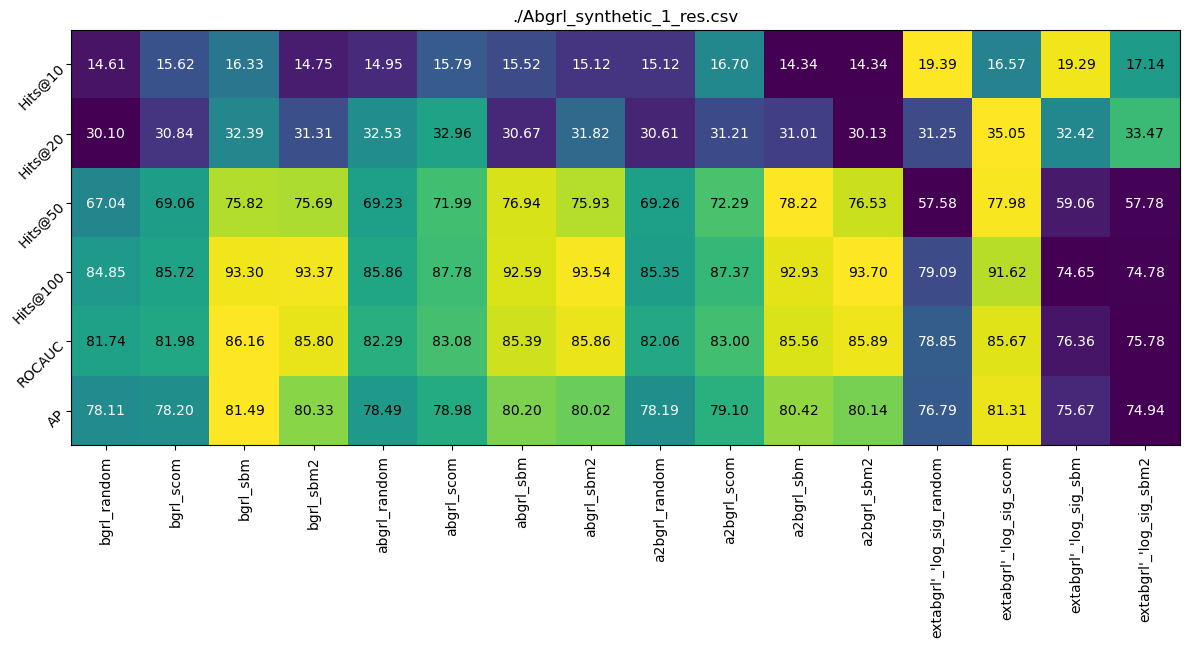

In [49]:
name_1 = './Abgrl_synthetic_1_res.csv'
data_1 = res_load(name_1)

name_2 = './extended_synthetic_1_res.csv'
data_2 = res_load(name_2)
data_2 = data_2[~data_2.index.str.contains('grace', case=False)]

data = pd.concat((data_1, data_2))
data=data[~data.index.str.contains('src', case=False)]

data_1.loc['avg_bgrl'] = average_methods(data_1.loc[['bgrl_random', 'bgrl_scom', 'bgrl_sbm', 'bgrl_sbm2']])
data_1.loc['avg_abgrl'] = average_methods(data_1.loc[['abgrl_random', 'abgrl_scom', 'abgrl_sbm', 'abgrl_sbm2']])
data_1.loc['avg_a2bgrl'] = average_methods(data_1.loc[['a2bgrl_random', 'a2bgrl_scom', 'a2bgrl_sbm', 'a2bgrl_sbm2']])
data_1.loc['avg_asrcbgrl'] = average_methods(data_1.loc[['asrcbgrl_random', 'asrcbgrl_scom', 'asrcbgrl_sbm', 'asrcbgrl_sbm2']])
heatmap(data_1.loc[['avg_bgrl', 'avg_abgrl', 'avg_a2bgrl', 'avg_asrcbgrl']], 'avg_'+name_1, (5,5))
heatmap(data_1.loc[['bgrl_sbm', 'abgrl_sbm', 'a2bgrl_sbm', 'asrcbgrl_sbm']], 'avg_'+name_1, (5,5))
heatmap(data_1.loc[['bgrl_sbm2', 'abgrl_sbm2', 'a2bgrl_sbm2', 'asrcbgrl_sbm2']], 'avg_'+name_1, (5,5))

print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name_1, (12,12))

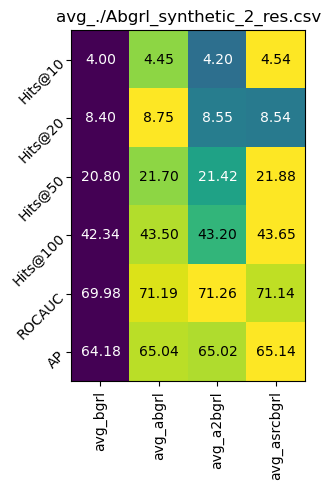

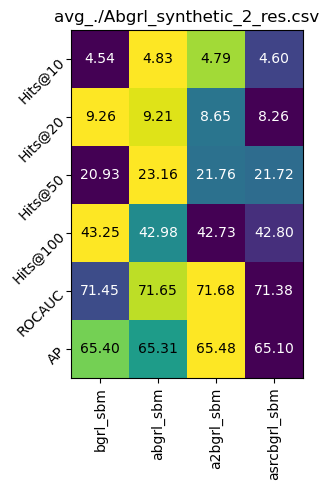

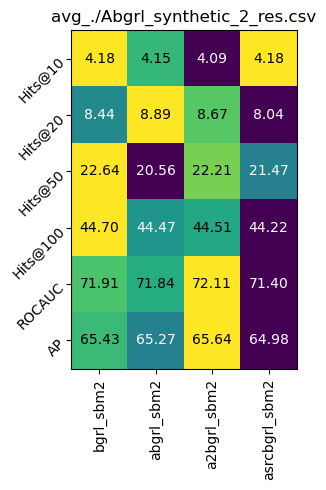

./Abgrl_synthetic_2_res.csv


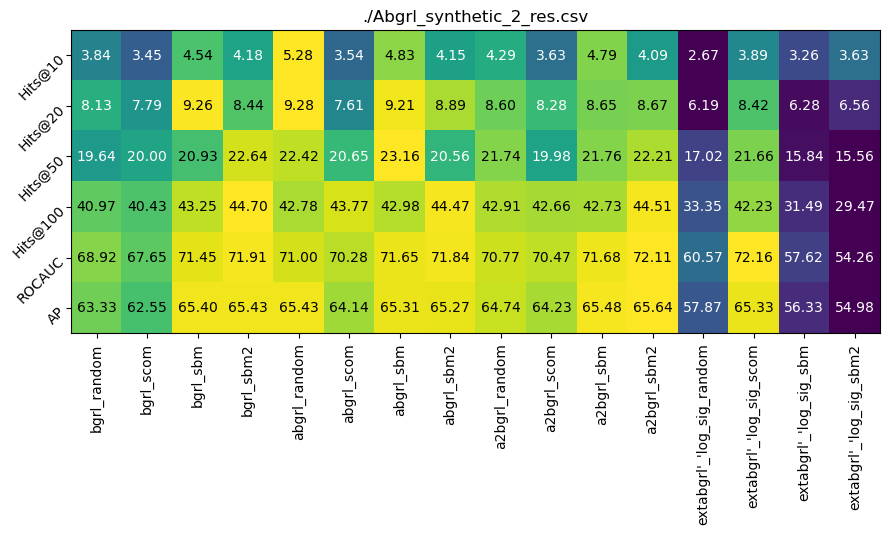

In [50]:
name_1 = './Abgrl_synthetic_2_res.csv'
data_1 = res_load(name_1)

name_2 = './extended_synthetic_2_res.csv'
data_2 = res_load(name_2)
data_2 = data_2[~data_2.index.str.contains('grace', case=False)]

data = pd.concat((data_1, data_2))
data=data[~data.index.str.contains('src', case=False)]


data_1.loc['avg_bgrl'] = average_methods(data_1.loc[['bgrl_random', 'bgrl_scom', 'bgrl_sbm', 'bgrl_sbm2']])
data_1.loc['avg_abgrl'] = average_methods(data_1.loc[['abgrl_random', 'abgrl_scom', 'abgrl_sbm', 'abgrl_sbm2']])
data_1.loc['avg_a2bgrl'] = average_methods(data_1.loc[['a2bgrl_random', 'a2bgrl_scom', 'a2bgrl_sbm', 'a2bgrl_sbm2']])
data_1.loc['avg_asrcbgrl'] = average_methods(data_1.loc[['asrcbgrl_random', 'asrcbgrl_scom', 'asrcbgrl_sbm', 'asrcbgrl_sbm2']])
heatmap(data_1.loc[['avg_bgrl', 'avg_abgrl', 'avg_a2bgrl', 'avg_asrcbgrl']], 'avg_'+name_1, (5,5))
heatmap(data_1.loc[['bgrl_sbm', 'abgrl_sbm', 'a2bgrl_sbm', 'asrcbgrl_sbm']], 'avg_'+name_1, (5,5))
heatmap(data_1.loc[['bgrl_sbm2', 'abgrl_sbm2', 'a2bgrl_sbm2', 'asrcbgrl_sbm2']], 'avg_'+name_1, (5,5))

print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name_1, (9,9))

./Abgrl_synthetic_3_res.csv


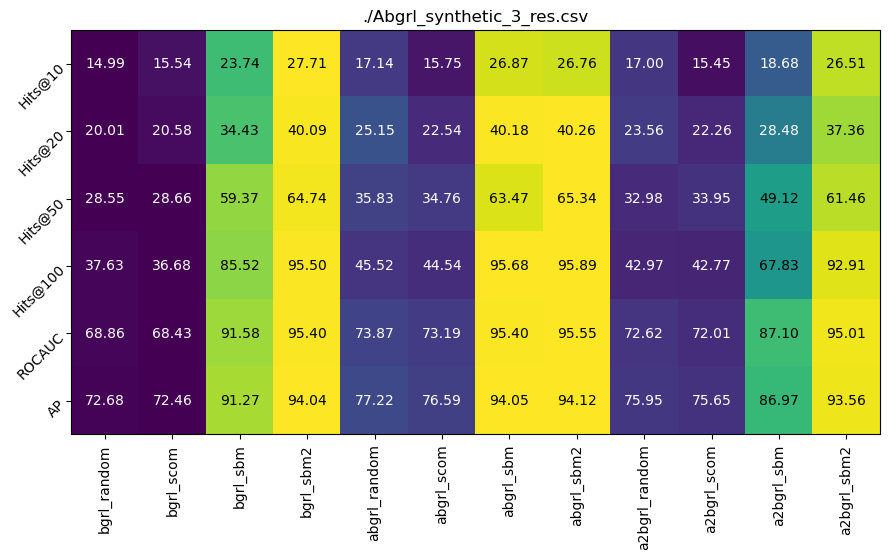

In [52]:
name_1 = './Abgrl_synthetic_3_res.csv'
data_1 = res_load(name_1)

data_1=data_1[~data_1.index.str.contains('src', case=False)]

print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data_1, name_1, (9,9))

### link-grace

./lgrace_cora_res.csv


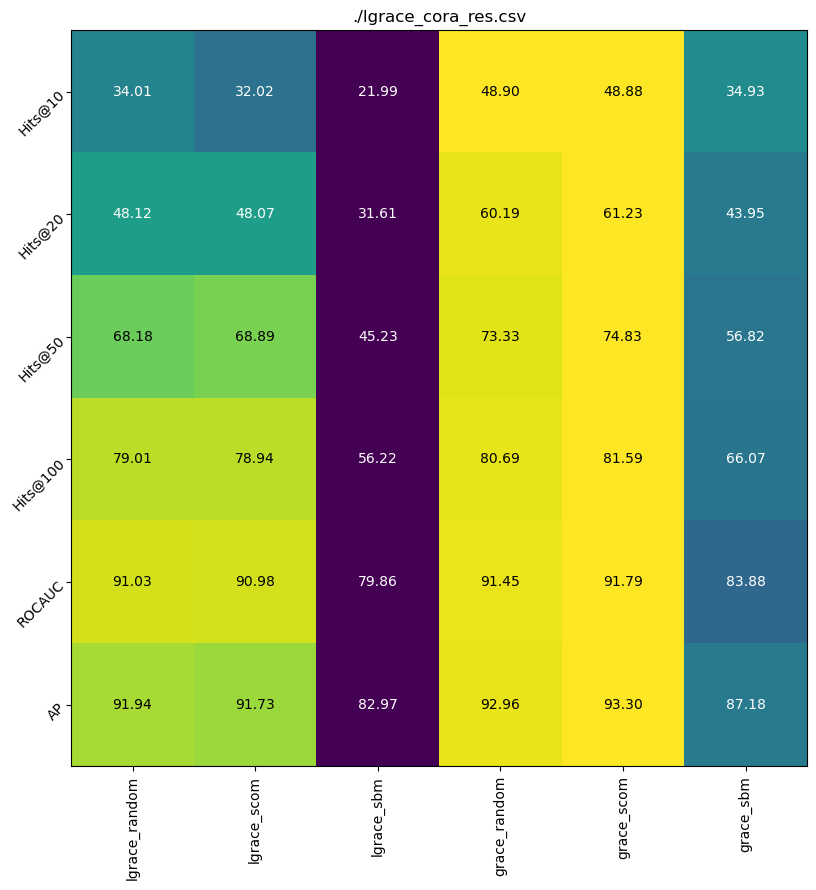

,lgrace_random,lgrace_scom,lgrace_sbm,grace_random,grace_scom,grace_sbm
metrics,,,,,,
Hits@10,34.01$\pm$6.52,32.02$\pm$3.95,21.99$\pm$4.65,48.9$\pm$4.88,48.88$\pm$6.25,34.93$\pm$4.84
Hits@20,48.12$\pm$4.71,48.07$\pm$4.81,31.61$\pm$3.24,60.19$\pm$2.76,61.23$\pm$4.28,43.95$\pm$3.63
Hits@50,68.18$\pm$2.32,68.89$\pm$2.97,45.23$\pm$1.47,73.33$\pm$1.73,74.83$\pm$1.53,56.82$\pm$2.11
Hits@100,79.01$\pm$1.67,78.94$\pm$1.05,56.22$\pm$2.27,80.69$\pm$1.6,81.59$\pm$1.4,66.07$\pm$2.04
ROCAUC,91.03$\pm$0.76,90.98$\pm$0.51,79.86$\pm$1.31,91.45$\pm$0.81,91.79$\pm$0.71,83.88$\pm$1.02
AP,91.94$\pm$0.58,91.73$\pm$0.48,82.97$\pm$0.78,92.96$\pm$0.6,93.3$\pm$0.44,87.18$\pm$0.72
pretrain_time,83.32$\pm$0.86,83.33$\pm$0.72,402.89$\pm$16.21,19.04$\pm$0.13,20.27$\pm$0.09,866.8$\pm$23.27


In [3]:
name_1 = './lgrace_cora_res.csv'
data_1 = res_load(name_1)

name_2 = './full_output_cora_res.csv'
data_2 = res_load(name_2)
data_2 = data_2.T[['grace_random', 'grace_scom', 'grace_sbm']].T

data = pd.concat([data_1, data_2])


print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name_1, (9,9))
display(data.T)

./new_lgrace_synthetic_1_res.csv


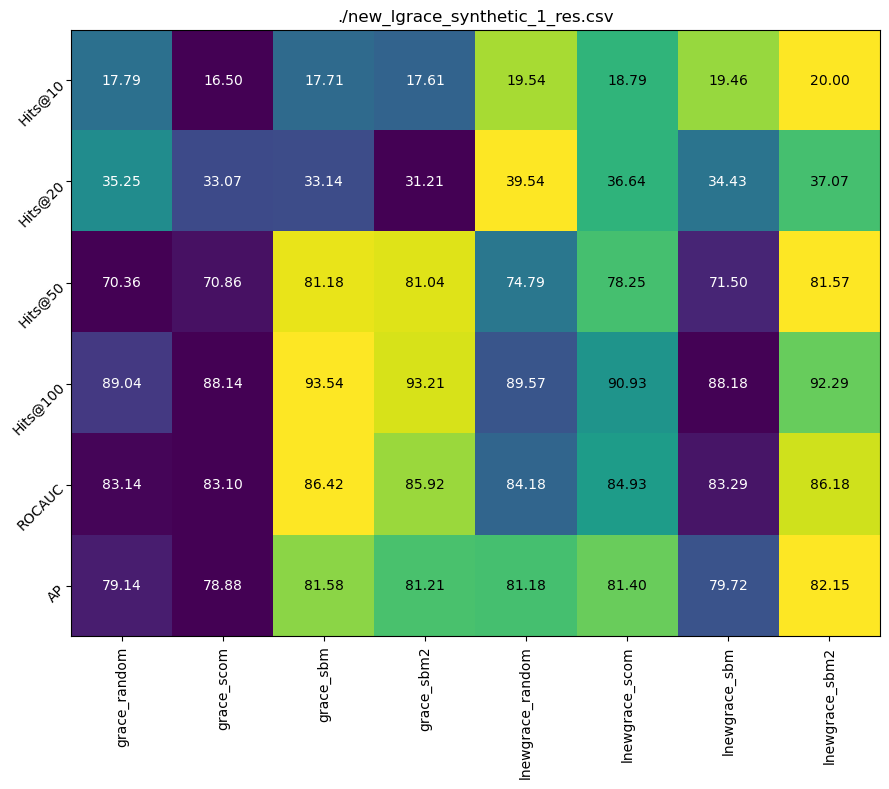

,grace_random,grace_scom,grace_sbm,grace_sbm2,lnewgrace_random,lnewgrace_scom,lnewgrace_sbm,lnewgrace_sbm2
metrics,,,,,,,,
Hits@10,17.79$\pm$7.26,16.5$\pm$6.84,17.71$\pm$5.37,17.61$\pm$5.64,19.54$\pm$2.97,18.79$\pm$5.35,19.46$\pm$6.42,20.0$\pm$4.78
Hits@20,35.25$\pm$9.67,33.07$\pm$7.54,33.14$\pm$8.16,31.21$\pm$5.66,39.54$\pm$8.43,36.64$\pm$6.4,34.43$\pm$9.45,37.07$\pm$6.97
Hits@50,70.36$\pm$4.24,70.86$\pm$5.75,81.18$\pm$10.02,81.04$\pm$11.84,74.79$\pm$9.07,78.25$\pm$9.37,71.5$\pm$18.09,81.57$\pm$9.98
Hits@100,89.04$\pm$0.6,88.14$\pm$2.23,93.54$\pm$1.12,93.21$\pm$1.01,89.57$\pm$2.06,90.93$\pm$1.81,88.18$\pm$8.94,92.29$\pm$1.29
ROCAUC,83.14$\pm$1.49,83.1$\pm$1.4,86.42$\pm$1.6,85.92$\pm$1.75,84.18$\pm$2.24,84.93$\pm$1.75,83.29$\pm$5.57,86.18$\pm$2.13
AP,79.14$\pm$2.4,78.88$\pm$2.35,81.58$\pm$2.58,81.21$\pm$2.81,81.18$\pm$2.69,81.4$\pm$2.7,79.72$\pm$5.5,82.15$\pm$2.48
pretrain_time,4.08$\pm$0.1,4.68$\pm$0.01,33.48$\pm$0.23,62.35$\pm$0.15,8.45$\pm$0.16,8.29$\pm$0.7,38.13$\pm$0.14,73.47$\pm$9.24


In [7]:
name_1 = './new_lgrace_synthetic_1_res.csv'
data_1 = res_load(name_1)

name_2 = './sbm_full_synthetic_1_res.csv'
data_2 = res_load(name_2)
data_2 = data_2.T[['grace_random', 'grace_scom', 'grace_sbm','grace_sbm2']].T

name_3 = './ReNew_lGrace_synthetic_1_res.csv'
data_3 = res_load(name_3)

data = pd.concat([data_2, data_3])


print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name_1, (9,9))
display(data.T)

./new_lgrace_synthetic_2_res.csv


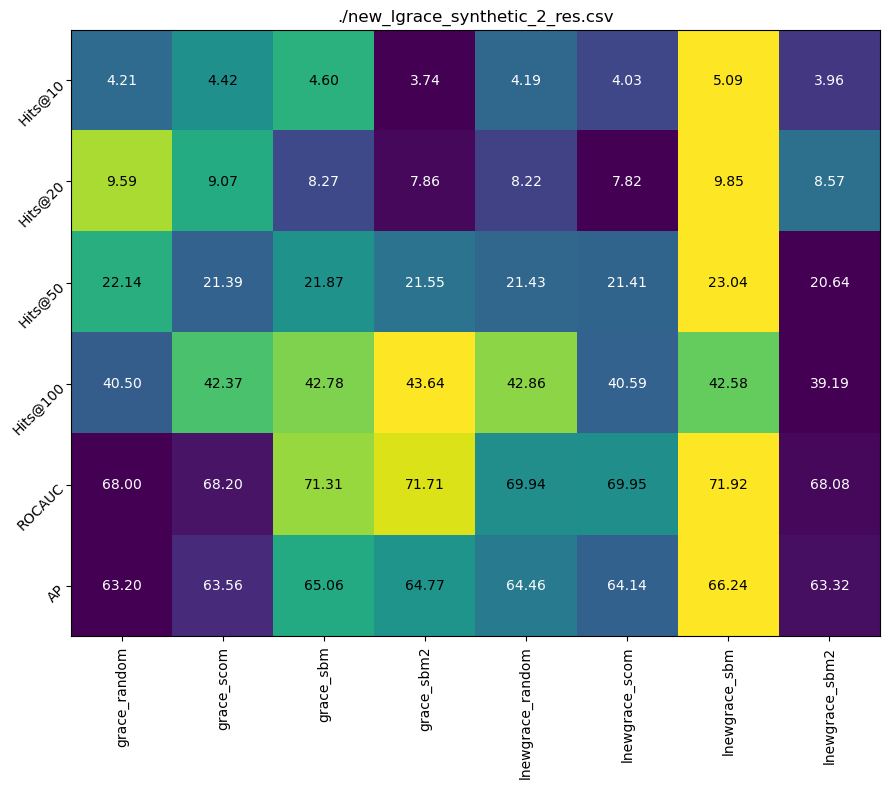

,grace_random,grace_scom,grace_sbm,grace_sbm2,lnewgrace_random,lnewgrace_scom,lnewgrace_sbm,lnewgrace_sbm2
metrics,,,,,,,,
Hits@10,4.21$\pm$1.93,4.42$\pm$0.92,4.6$\pm$1.26,3.74$\pm$1.5,4.19$\pm$1.91,4.03$\pm$1.55,5.09$\pm$1.23,3.96$\pm$1.63
Hits@20,9.59$\pm$2.41,9.07$\pm$2.06,8.27$\pm$1.92,7.86$\pm$2.03,8.22$\pm$2.42,7.82$\pm$1.6,9.85$\pm$2.14,8.57$\pm$4.21
Hits@50,22.14$\pm$4.09,21.39$\pm$4.06,21.87$\pm$2.69,21.55$\pm$2.52,21.43$\pm$3.43,21.41$\pm$2.39,23.04$\pm$3.03,20.64$\pm$8.26
Hits@100,40.5$\pm$5.55,42.37$\pm$4.4,42.78$\pm$3.2,43.64$\pm$3.57,42.86$\pm$2.99,40.59$\pm$3.93,42.58$\pm$3.22,39.19$\pm$15.29
ROCAUC,68.0$\pm$2.32,68.2$\pm$2.15,71.31$\pm$1.51,71.71$\pm$1.48,69.94$\pm$1.66,69.95$\pm$1.67,71.92$\pm$1.36,68.08$\pm$9.53
AP,63.2$\pm$2.67,63.56$\pm$2.21,65.06$\pm$1.51,64.77$\pm$1.77,64.46$\pm$2.11,64.14$\pm$1.87,66.24$\pm$1.44,63.32$\pm$6.91
pretrain_time,3.96$\pm$0.05,4.55$\pm$0.05,47.69$\pm$0.26,91.37$\pm$0.69,8.44$\pm$0.05,8.22$\pm$0.5,56.07$\pm$0.34,128.62$\pm$23.04


In [8]:
name_1 = './new_lgrace_synthetic_2_res.csv'
data_1 = res_load(name_1)

name_2 = './sbm_full_synthetic_2_res.csv'
data_2 = res_load(name_2)
data_2 = data_2.T[['grace_random', 'grace_scom', 'grace_sbm','grace_sbm2']].T

name_3 = './ReNew_lGrace_synthetic_2_res.csv'
data_3 = res_load(name_3)

data = pd.concat([data_2, data_3])


print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name_1, (9,9))
display(data.T)

./new_lgrace_synthetic_3_res.csv


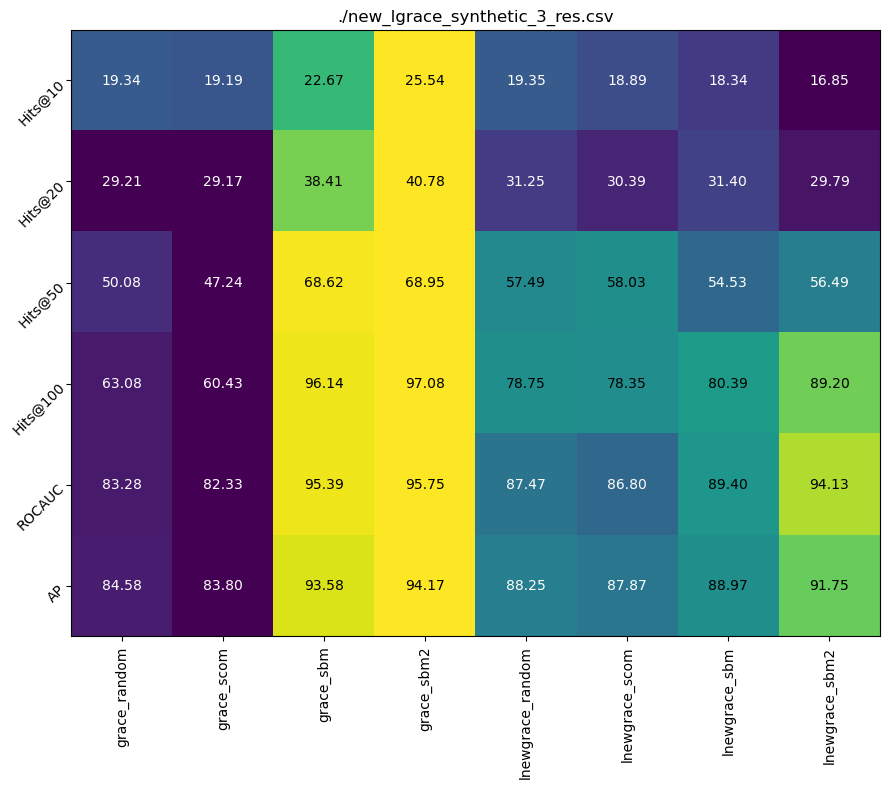

,grace_random,grace_scom,grace_sbm,grace_sbm2,lnewgrace_random,lnewgrace_scom,lnewgrace_sbm,lnewgrace_sbm2
metrics,,,,,,,,
Hits@10,19.34$\pm$4.15,19.19$\pm$2.74,22.67$\pm$6.13,25.54$\pm$5.67,19.35$\pm$4.08,18.89$\pm$2.7,18.34$\pm$4.76,16.85$\pm$4.08
Hits@20,29.21$\pm$4.44,29.17$\pm$4.24,38.41$\pm$9.15,40.78$\pm$7.11,31.25$\pm$6.34,30.39$\pm$4.01,31.4$\pm$7.28,29.79$\pm$6.98
Hits@50,50.08$\pm$3.33,47.24$\pm$3.29,68.62$\pm$6.61,68.95$\pm$8.8,57.49$\pm$5.68,58.03$\pm$5.5,54.53$\pm$8.38,56.49$\pm$8.61
Hits@100,63.08$\pm$1.66,60.43$\pm$2.02,96.14$\pm$1.98,97.08$\pm$2.71,78.75$\pm$2.79,78.35$\pm$2.7,80.39$\pm$4.19,89.2$\pm$7.35
ROCAUC,83.28$\pm$0.68,82.33$\pm$0.91,95.39$\pm$0.71,95.75$\pm$0.6,87.47$\pm$1.08,86.8$\pm$1.32,89.4$\pm$1.26,94.13$\pm$1.15
AP,84.58$\pm$0.6,83.8$\pm$0.97,93.58$\pm$1.19,94.17$\pm$0.94,88.25$\pm$1.09,87.87$\pm$0.93,88.97$\pm$1.38,91.75$\pm$1.69
pretrain_time,6.92$\pm$0.01,7.56$\pm$0.01,177.71$\pm$0.41,350.9$\pm$1.0,12.91$\pm$0.32,13.63$\pm$0.42,220.43$\pm$24.14,410.24$\pm$40.13


In [9]:
name_1 = './new_lgrace_synthetic_3_res.csv'
data_1 = res_load(name_1)

name_2 = './sbm_full_synthetic_3_res.csv'
data_2 = res_load(name_2)
data_2 = data_2.T[['grace_random', 'grace_scom', 'grace_sbm','grace_sbm2']].T

name_3 = './ReNew_lGrace_synthetic_3_res.csv'
data_3 = res_load(name_3)

data = pd.concat([data_2, data_3])


print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name_1, (9,9))
display(data.T)

# Loss Compare

./loss_compare_synthetic_1_res.csv


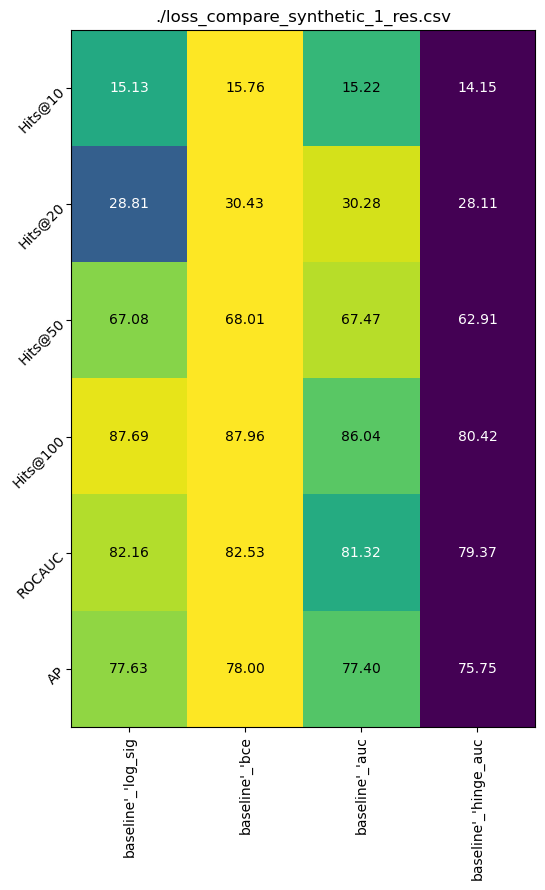

metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC,AP,pretrain_time
baseline'_'log_sig,15.13$\pm$6.96,28.81$\pm$9.44,67.08$\pm$5.51,87.69$\pm$1.59,82.16$\pm$1.97,77.63$\pm$2.88,nan$\pm$nan
baseline'_'bce,15.76$\pm$6.67,30.43$\pm$9.24,68.01$\pm$6.49,87.96$\pm$2.09,82.53$\pm$2.22,78.0$\pm$3.16,nan$\pm$nan
baseline'_'auc,15.22$\pm$6.26,30.28$\pm$8.94,67.47$\pm$5.9,86.04$\pm$3.48,81.32$\pm$2.73,77.4$\pm$3.08,nan$\pm$nan
baseline'_'hinge_auc,14.15$\pm$8.05,28.11$\pm$13.15,62.91$\pm$18.94,80.42$\pm$23.19,79.37$\pm$8.82,75.75$\pm$7.99,nan$\pm$nan


In [3]:
name_1 = './loss_compare_synthetic_1_res.csv'
data_1 = res_load(name_1)

print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data_1, name_1, (9,9))
display(data_1)

./loss_compare_synthetic_2_res.csv


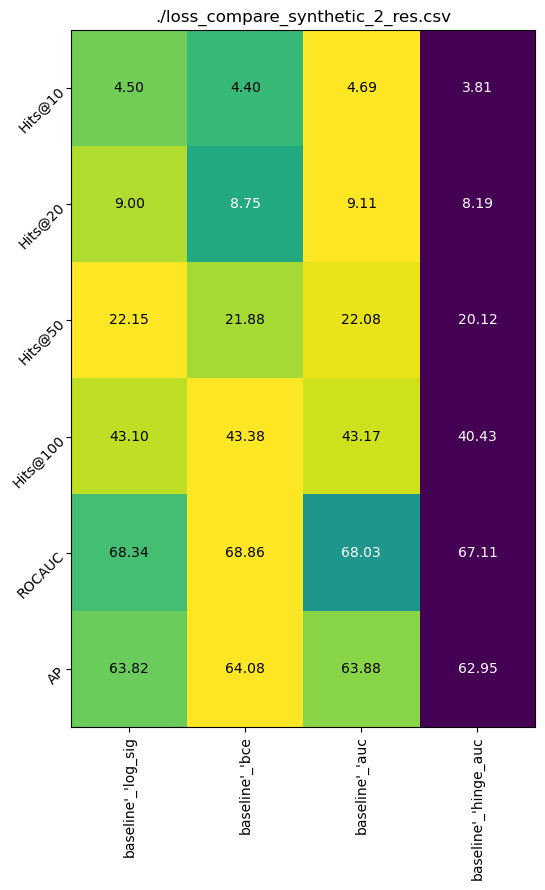

metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC,AP,pretrain_time
baseline'_'log_sig,4.5$\pm$1.43,9.0$\pm$2.83,22.15$\pm$4.6,43.1$\pm$4.14,68.34$\pm$1.39,63.82$\pm$2.26,nan$\pm$nan
baseline'_'bce,4.4$\pm$1.52,8.75$\pm$2.46,21.88$\pm$3.74,43.38$\pm$4.21,68.86$\pm$1.75,64.08$\pm$2.13,nan$\pm$nan
baseline'_'auc,4.69$\pm$1.41,9.11$\pm$2.24,22.08$\pm$3.42,43.17$\pm$4.36,68.03$\pm$2.23,63.88$\pm$2.09,nan$\pm$nan
baseline'_'hinge_auc,3.81$\pm$2.1,8.19$\pm$3.19,20.12$\pm$6.72,40.43$\pm$10.32,67.11$\pm$4.48,62.95$\pm$3.66,nan$\pm$nan


In [5]:
name_1 = './loss_compare_synthetic_2_res.csv'
data_1 = res_load(name_1)

print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data_1, name_1, (9,9))
display(data_1)

./loss_compare_synthetic_3_res.csv


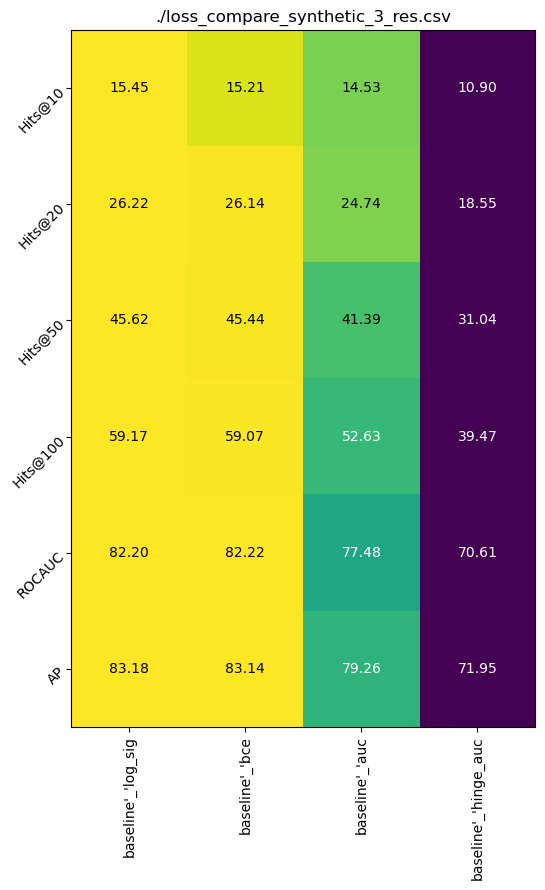

metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC,AP,pretrain_time
baseline'_'log_sig,15.45$\pm$2.13,26.22$\pm$3.0,45.62$\pm$2.24,59.17$\pm$2.33,82.2$\pm$0.69,83.18$\pm$0.47,nan$\pm$nan
baseline'_'bce,15.21$\pm$2.32,26.14$\pm$3.34,45.44$\pm$2.21,59.07$\pm$2.34,82.22$\pm$0.97,83.14$\pm$0.82,nan$\pm$nan
baseline'_'auc,14.53$\pm$3.93,24.74$\pm$5.63,41.39$\pm$8.91,52.63$\pm$12.69,77.48$\pm$8.11,79.26$\pm$7.08,nan$\pm$nan
baseline'_'hinge_auc,10.9$\pm$7.15,18.55$\pm$11.77,31.04$\pm$19.51,39.47$\pm$25.3,70.61$\pm$13.82,71.95$\pm$14.08,nan$\pm$nan


In [6]:
name_1 = './loss_compare_synthetic_3_res.csv'
data_1 = res_load(name_1)

print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data_1, name_1, (9,9))
display(data_1)

./loss_compare_cora_res.csv


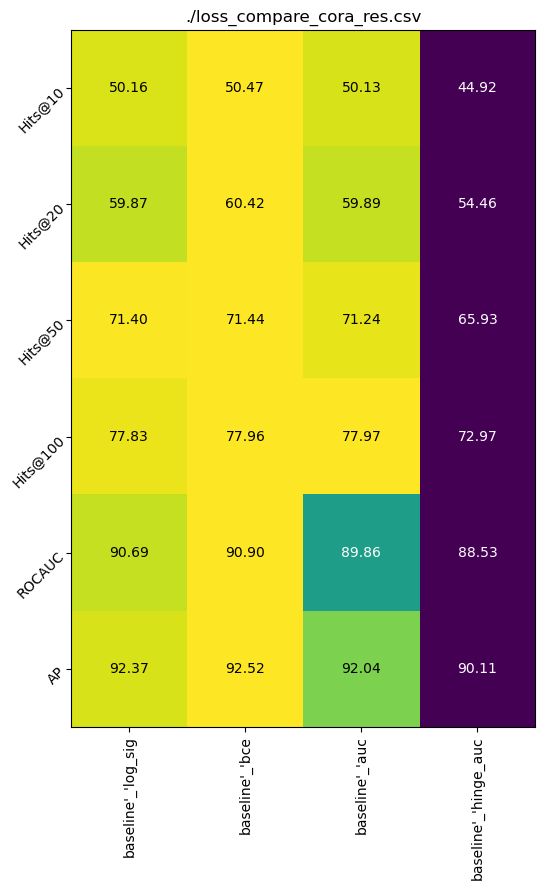

metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC,AP,pretrain_time
baseline'_'log_sig,50.16$\pm$4.8,59.87$\pm$2.78,71.4$\pm$1.62,77.83$\pm$2.01,90.69$\pm$0.88,92.37$\pm$0.67,nan$\pm$nan
baseline'_'bce,50.47$\pm$4.36,60.42$\pm$2.95,71.44$\pm$1.77,77.96$\pm$1.88,90.9$\pm$0.83,92.52$\pm$0.64,nan$\pm$nan
baseline'_'auc,50.13$\pm$4.9,59.89$\pm$3.31,71.24$\pm$1.96,77.97$\pm$1.93,89.86$\pm$1.71,92.04$\pm$0.94,nan$\pm$nan
baseline'_'hinge_auc,44.92$\pm$14.45,54.46$\pm$16.35,65.93$\pm$17.06,72.97$\pm$17.93,88.53$\pm$5.73,90.11$\pm$7.06,nan$\pm$nan


In [7]:
name_1 = './loss_compare_cora_res.csv'
data_1 = res_load(name_1)

print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data_1, name_1, (9,9))
display(data_1)

./loss_compare_citeseer_res.csv


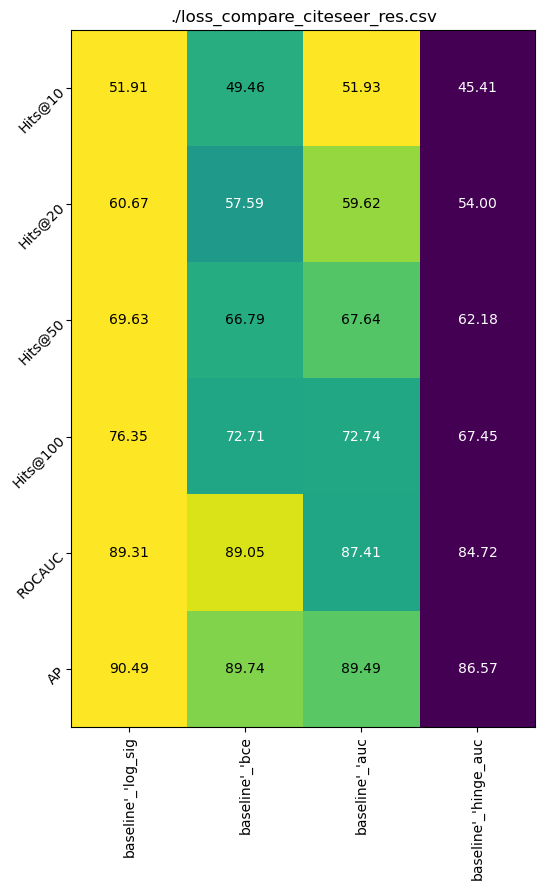

metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC,AP,pretrain_time
baseline'_'log_sig,51.91$\pm$14.74,60.67$\pm$12.12,69.63$\pm$10.11,76.35$\pm$8.5,89.31$\pm$5.75,90.49$\pm$6.59,nan$\pm$nan
baseline'_'bce,49.46$\pm$17.1,57.59$\pm$16.86,66.79$\pm$17.3,72.71$\pm$18.41,89.05$\pm$6.46,89.74$\pm$8.26,nan$\pm$nan
baseline'_'auc,51.93$\pm$14.51,59.62$\pm$14.12,67.64$\pm$14.21,72.74$\pm$15.08,87.41$\pm$5.9,89.49$\pm$6.79,nan$\pm$nan
baseline'_'hinge_auc,45.41$\pm$20.17,54.0$\pm$20.07,62.18$\pm$21.64,67.45$\pm$23.22,84.72$\pm$11.08,86.57$\pm$11.92,nan$\pm$nan


In [9]:
name_1 = './loss_compare_citeseer_res.csv'
data_1 = res_load(name_1)

print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data_1, name_1, (9,9))
display(data_1)

./loss_compare_pubmed_res.csv


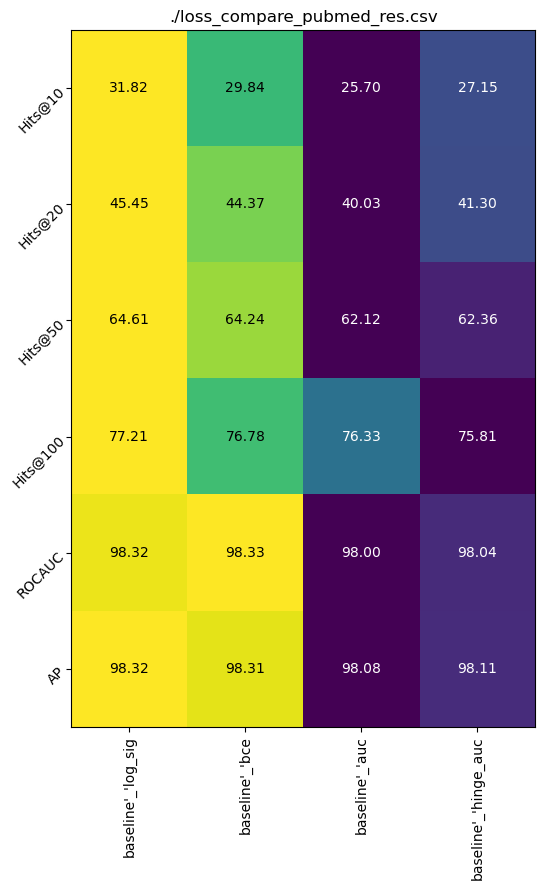

metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC,AP,pretrain_time
baseline'_'log_sig,31.82$\pm$4.96,45.45$\pm$4.26,64.61$\pm$1.84,77.21$\pm$1.79,98.32$\pm$0.13,98.32$\pm$0.12,nan$\pm$nan
baseline'_'bce,29.84$\pm$5.25,44.37$\pm$5.32,64.24$\pm$2.68,76.78$\pm$1.8,98.33$\pm$0.11,98.31$\pm$0.12,nan$\pm$nan
baseline'_'auc,25.7$\pm$7.62,40.03$\pm$8.53,62.12$\pm$4.47,76.33$\pm$2.29,98.0$\pm$0.5,98.08$\pm$0.36,nan$\pm$nan
baseline'_'hinge_auc,27.15$\pm$7.47,41.3$\pm$7.89,62.36$\pm$4.16,75.81$\pm$2.47,98.04$\pm$0.45,98.11$\pm$0.32,nan$\pm$nan


In [11]:
name_1 = './loss_compare_pubmed_res.csv'
data_1 = res_load(name_1)

print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data_1, name_1, (9,9))
display(data_1)

./loss_compare_collab_res.csv


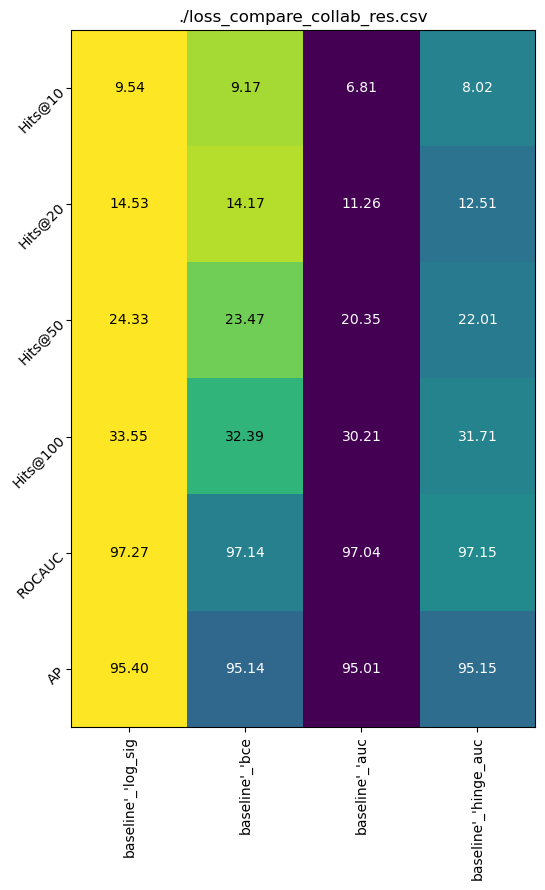

metrics,Hits@10,Hits@20,Hits@50,Hits@100,ROCAUC,AP,pretrain_time
baseline'_'log_sig,9.54$\pm$1.86,14.53$\pm$1.77,24.33$\pm$1.86,33.55$\pm$1.75,97.27$\pm$0.05,95.4$\pm$0.12,nan$\pm$nan
baseline'_'bce,9.17$\pm$1.82,14.17$\pm$1.96,23.47$\pm$2.33,32.39$\pm$2.56,97.14$\pm$0.35,95.14$\pm$0.65,nan$\pm$nan
baseline'_'auc,6.81$\pm$3.7,11.26$\pm$4.46,20.35$\pm$4.96,30.21$\pm$4.29,97.04$\pm$0.32,95.01$\pm$0.58,nan$\pm$nan
baseline'_'hinge_auc,8.02$\pm$3.92,12.51$\pm$4.54,22.01$\pm$5.25,31.71$\pm$4.6,97.15$\pm$0.33,95.15$\pm$0.57,nan$\pm$nan


In [12]:
name_1 = './loss_compare_collab_res.csv'
data_1 = res_load(name_1)

print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data_1, name_1, (9,9))
display(data_1)